# Анализ сходимости алгоритма: зависимость от Beta и Gamma
Этот ноутбук запускает grid search по параметрам beta (inverse temperature) и gamma (discount factor),
анализирует сходимость и строит heat-map результатов.

In [62]:
# Настройка путей для импорта exp4
import os, sys
from pathlib import Path

exp4_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(exp4_path, 'continuous_game.py')):
    repo_root = Path(os.getcwd()).resolve()
    alt = os.path.join(str(repo_root), 'experiments', 'exp4')
    if os.path.exists(os.path.join(alt, 'continuous_game.py')):
        exp4_path = alt

if exp4_path not in sys.path:
    sys.path.insert(0, exp4_path)
print('📦 sys.path настроен для exp4:', exp4_path)

📦 sys.path настроен для exp4: /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm import tqdm

from continuous_game import ContinuousBimatrixGame, PayoffParams
from softmax_sarsa_agent import SoftmaxSARSAAgent
from viz import check_convergence, plot_joint_convergence_heatmap, plot_action_value_heatmaps

print('✅ Импорты готовы')

✅ Импорты готовы


## 1. Запуск Grid Search
Перебираем комбинации beta × gamma, обучаем агентов и проверяем сходимость.

In [ ]:
def run_single_experiment(beta: float, gamma: float,
                          params: PayoffParams,
                          n: int = 100,
                          steps: int = 50000,
                          alpha: float = 0.01,
                          init_mode: str = 'uniform',
                          seed: int = 42) -> dict:
    """Запускает один эксперимент и возвращает детальную информацию о сходимости."""
    game = ContinuousBimatrixGame(params, n=n)
    agent_a = SoftmaxSARSAAgent(game.num_actions(), alpha=alpha, gamma=gamma,
                                beta=beta, init_mode=init_mode, seed=seed)
    agent_b = SoftmaxSARSAAgent(game.num_actions(), alpha=alpha, gamma=gamma,
                                beta=beta, init_mode=init_mode, seed=seed + 1)
    
    policies_a = []
    policies_b = []
    
    a = agent_a.start_episode()
    b = agent_b.start_episode()
    
    for _ in range(steps):
        r_a = game.payoff_player0(a, b)
        r_b = game.payoff_player1(a, b)
        next_a = agent_a.choose_action()
        next_b = agent_b.choose_action()
        agent_a.step(r_a, next_action=next_a)
        agent_b.step(r_b, next_action=next_b)
        policies_a.append(agent_a.get_action_probs())
        policies_b.append(agent_b.get_action_probs())
        a, b = next_a, next_b
    
    # Проверяем сходимость с передачей сетки действий
    actions = game.grid()
    conv_a = check_convergence(policies_a, window=5000,
                               threshold_converged=1e-3,
                               actions=actions)
    conv_b = check_convergence(policies_b, window=5000,
                               threshold_converged=1e-3,
                               actions=actions)
    
    return {
        'beta': beta,
        'gamma': gamma,
        'conv_a': conv_a,  # словарь с детальной информацией
        'conv_b': conv_b   # словарь с детальной информацией
    }

In [65]:
# Параметры сетки (как в bash-скрипте grid_search_beta_gamma.sh)
# Эти комбинации уже есть в results/grid_beta_gamma/without_init_mode/
beta_values = [0.01, 0.1, 0.3, 1.0, 5.0]
gamma_values = [0.0, 0.2, 0.5, 0.95]

# ВНИМАНИЕ! Расширенная сетка требует:
# 1. Больше шагов обучения (steps >> 3000)
# 2. Другие пороги сходимости
# 3. Адаптивную визуализацию
# 
# Раскомментируйте с осторожностью:
beta_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.65, 0.7, 0.76, 0.8, 0.9, 1.0, 2.0, 5.0]
gamma_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
steps = 50000  # Увеличьте для больших beta/gamma!

# Параметры игры (Prisoner's Dilemma-like)
params = PayoffParams(r=3.0, p=4.0, q=0.0, s=1.0)

# Параметры обучения (из bash-скрипта)
n = 100  # дискретизация [0,1] на 21 точку
# steps = 3000
alpha = 0.01
init_mode = 'uniform'
seed = 42

print(f"🔬 Запускаем grid search: {len(beta_values)} beta × {len(gamma_values)} gamma = {len(beta_values)*len(gamma_values)} экспериментов")
print(f"Beta values: {beta_values}")
print(f"Gamma values: {gamma_values}")
print(f"Параметры: n={n}, steps={steps}, alpha={alpha}, init_mode={init_mode}, seed={seed}")
print(f"Игра: r={params.r}, p={params.p}, q={params.q}, s={params.s}")
print(f"\n💡 Примечание: Текущая сетка соответствует bash-скрипту (результаты в grid_beta_gamma/)")

🔬 Запускаем grid search: 14 beta × 12 gamma = 168 экспериментов
Beta values: [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.65, 0.7, 0.76, 0.8, 0.9, 1.0, 2.0, 5.0]
Gamma values: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
Параметры: n=100, steps=50000, alpha=0.01, init_mode=uniform, seed=42
Игра: r=3.0, p=4.0, q=0.0, s=1.0

💡 Примечание: Текущая сетка соответствует bash-скрипту (результаты в grid_beta_gamma/)


### 📊 Анализ существующих результатов

Можно сначала загрузить уже имеющиеся результаты из `grid_beta_gamma/without_init_mode/` вместо повторного запуска экспериментов.

In [66]:
import os
from pathlib import Path

# Проверяем, какие файлы уже есть
results_dir = Path('../results/grid_beta_gamma/without_init_mode')
if results_dir.exists():
    existing_files = sorted([f.name for f in results_dir.glob('beta*_gamma*.png')])
    print(f"✅ Найдено {len(existing_files)} существующих результатов:\n")
    
    # Группируем по beta
    from collections import defaultdict
    by_beta = defaultdict(list)
    for fname in existing_files:
        # beta0.01_gamma0.0.png → beta=0.01, gamma=0.0
        parts = fname.replace('.png', '').split('_')
        beta = parts[0].replace('beta', '')
        gamma = parts[1].replace('gamma', '')
        by_beta[beta].append(gamma)
    
    for beta in sorted(by_beta.keys(), key=float):
        gammas = ', '.join(sorted(by_beta[beta], key=float))
        print(f"  β={beta:>4s}: γ ∈ [{gammas}]")
    
    # Проверяем, какие комбинации из текущей сетки отсутствуют
    missing = []
    for beta in beta_values:
        for gamma in gamma_values:
            expected_file = results_dir / f"beta{beta}_gamma{gamma}.png"
            if not expected_file.exists():
                missing.append((beta, gamma))
    
    if missing:
        print(f"\n⚠️ Отсутствует {len(missing)} комбинаций:")
        for beta, gamma in missing:
            print(f"  β={beta}, γ={gamma}")
    else:
        print(f"\n✨ Все {len(beta_values)*len(gamma_values)} комбинаций уже существуют!")
        print("💡 Можно пропустить grid search и перейти к визуализации")
else:
    print(f"📂 Директория {results_dir} не найдена")
    print("🔬 Нужно запустить grid search для генерации результатов")

✅ Найдено 20 существующих результатов:

  β=0.01: γ ∈ [0.0, 0.2, 0.5, 0.95]
  β= 0.1: γ ∈ [0.0, 0.2, 0.5, 0.95]
  β= 0.3: γ ∈ [0.0, 0.2, 0.5, 0.95]
  β= 1.0: γ ∈ [0.0, 0.2, 0.5, 0.95]
  β= 5.0: γ ∈ [0.0, 0.2, 0.5, 0.95]

⚠️ Отсутствует 148 комбинаций:
  β=0.01, γ=0.1
  β=0.01, γ=0.3
  β=0.01, γ=0.4
  β=0.01, γ=0.6
  β=0.01, γ=0.7
  β=0.01, γ=0.8
  β=0.01, γ=0.9
  β=0.01, γ=0.99
  β=0.05, γ=0.0
  β=0.05, γ=0.1
  β=0.05, γ=0.2
  β=0.05, γ=0.3
  β=0.05, γ=0.4
  β=0.05, γ=0.5
  β=0.05, γ=0.6
  β=0.05, γ=0.7
  β=0.05, γ=0.8
  β=0.05, γ=0.9
  β=0.05, γ=0.95
  β=0.05, γ=0.99
  β=0.1, γ=0.1
  β=0.1, γ=0.3
  β=0.1, γ=0.4
  β=0.1, γ=0.6
  β=0.1, γ=0.7
  β=0.1, γ=0.8
  β=0.1, γ=0.9
  β=0.1, γ=0.99
  β=0.2, γ=0.0
  β=0.2, γ=0.1
  β=0.2, γ=0.2
  β=0.2, γ=0.3
  β=0.2, γ=0.4
  β=0.2, γ=0.5
  β=0.2, γ=0.6
  β=0.2, γ=0.7
  β=0.2, γ=0.8
  β=0.2, γ=0.9
  β=0.2, γ=0.95
  β=0.2, γ=0.99
  β=0.3, γ=0.1
  β=0.3, γ=0.3
  β=0.3, γ=0.4
  β=0.3, γ=0.6
  β=0.3, γ=0.7
  β=0.3, γ=0.8
  β=0.3, γ=0.9
  β=0.3, γ=0.99
 

In [67]:
from tqdm import tqdm as _tqdm

# ЗАПУСК GRID SEARCH (быстрее, чем раньше: всего 20 экспериментов)
results = []
total = len(beta_values) * len(gamma_values)

pbar = _tqdm(total=total, desc='Grid search', unit='exp', leave=True)
converged_a = 0
converged_b = 0
both_converged = 0

for beta in beta_values:
    for gamma in gamma_values:
        result = run_single_experiment(beta=beta, gamma=gamma, params=params,
                                      n=n, steps=steps, alpha=alpha,
                                      init_mode=init_mode, seed=seed)
        results.append(result)

        a_conv = bool(result['conv_a']['converged'])
        b_conv = bool(result['conv_b']['converged'])

        if a_conv:
            converged_a += 1
        if b_conv:
            converged_b += 1
        if a_conv and b_conv:
            both_converged += 1

        status = f"A:{'✓' if a_conv else '✗'} B:{'✓' if b_conv else '✗'}"
        # Обновляем прогресс-бар и показываем подробности
        pbar.update(1)
        pbar.set_description(f"β={beta} γ={gamma}")
        pbar.set_postfix({
            'status': status,
            'A_done': f"{converged_a}/{len(results)}",
            'B_done': f"{converged_b}/{len(results)}",
            'both': both_converged
        })

pbar.close()

print(f"\n✅ Завершено {len(results)} экспериментов")

β=5.0 γ=0.99: 100%|██████████| 168/168 [05:52<00:00,  2.10s/exp, status=A:✓ B:✓, A_done=131/168, B_done=123/168, both=120]


✅ Завершено 168 экспериментов


## 2. Сохранение результатов

In [68]:
# Сохраняем в JSON
output_dir = Path(exp4_path) / 'results'
output_dir.mkdir(exist_ok=True)
output_file = output_dir / 'convergence_grid_search.json'

# Преобразуем numpy arrays в списки для JSON-сериализации
def make_serializable(obj):
    """Рекурсивно преобразует numpy arrays в списки для JSON."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serializable(item) for item in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return float(obj)
    else:
        return obj

results = make_serializable(results)

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump({
        'params': {
            'beta_values': beta_values,
            'gamma_values': gamma_values,
            'n': n,
            'steps': steps,
            'alpha': alpha,
            'init_mode': init_mode,
            'game_params': {'r': params.r, 'p': params.p, 'q': params.q, 's': params.s}
        },
        'results': results
    }, f, indent=2, ensure_ascii=False)

print(f"💾 Результаты сохранены в {output_file}")

💾 Результаты сохранены в /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/results/convergence_grid_search.json


## 3. Статистика сходимости

In [69]:
# Краткая статистика сходимости
converged_a_count = sum(1 for r in results if r['conv_a']['converged'])
converged_b_count = sum(1 for r in results if r['conv_b']['converged'])
both_converged = sum(1 for r in results if r['conv_a']['converged'] and r['conv_b']['converged'])

print("📊 Статистика сходимости:")
print(f"Agent A сошёлся: {converged_a_count}/{len(results)} ({100*converged_a_count/len(results):.1f}%)")
print(f"Agent B сошёлся: {converged_b_count}/{len(results)} ({100*converged_b_count/len(results):.1f}%)")
print(f"Оба сошлись:     {both_converged}/{len(results)} ({100*both_converged/len(results):.1f}%)")

# Показываем примеры того, куда сошлись
print("\n🎯 Примеры сходимости (первые 5 случаев, где оба сошлись):")
count = 0
for r in results:
    if r['conv_a']['converged'] and r['conv_b']['converged'] and count < 5:
        beta, gamma = r['beta'], r['gamma']
        val_a = r['conv_a']['argmax_value']
        val_b = r['conv_b']['argmax_value']
        prob_a = r['conv_a']['max_prob']
        prob_b = r['conv_b']['max_prob']
        print(f"  β={beta:.2f}, γ={gamma:.1f}: A→{val_a:.2f} (p={prob_a:.3f}), B→{val_b:.2f} (p={prob_b:.3f})")
        count += 1

📊 Статистика сходимости:
Agent A сошёлся: 131/168 (78.0%)
Agent B сошёлся: 123/168 (73.2%)
Оба сошлись:     120/168 (71.4%)

🎯 Примеры сходимости (первые 5 случаев, где оба сошлись):
  β=0.01, γ=0.0: A→0.07 (p=0.010), B→0.01 (p=0.010)
  β=0.01, γ=0.1: A→0.07 (p=0.010), B→0.01 (p=0.010)
  β=0.01, γ=0.2: A→0.07 (p=0.010), B→0.01 (p=0.010)
  β=0.01, γ=0.3: A→0.07 (p=0.010), B→0.01 (p=0.010)
  β=0.01, γ=0.4: A→0.07 (p=0.010), B→0.01 (p=0.010)


### 📈 Детальная статистика сошедшихся экспериментов

In [70]:
# Собираем детальные статистики для сошедшихся экспериментов
converged_both = [r for r in results if r['conv_a']['converged'] and r['conv_b']['converged']]

if len(converged_both) > 0:
    print(f"🔬 Анализ {len(converged_both)} экспериментов, где оба агента сошлись:\n")
    
    # === СТАТИСТИКА 1: Распределение по значениям действий ===
    print("1️⃣ К каким действиям сходятся агенты?")
    print("-" * 50)
    
    actions_a = [r['conv_a']['argmax_value'] for r in converged_both]
    actions_b = [r['conv_b']['argmax_value'] for r in converged_both]
    
    print(f"Agent A:")
    print(f"  Среднее действие: {np.mean(actions_a):.3f}")
    print(f"  Медиана:          {np.median(actions_a):.3f}")
    print(f"  Стд. отклонение:  {np.std(actions_a):.3f}")
    print(f"  Диапазон:         [{np.min(actions_a):.3f}, {np.max(actions_a):.3f}]")
    
    print(f"\nAgent B:")
    print(f"  Среднее действие: {np.mean(actions_b):.3f}")
    print(f"  Медиана:          {np.median(actions_b):.3f}")
    print(f"  Стд. отклонение:  {np.std(actions_b):.3f}")
    print(f"  Диапазон:         [{np.min(actions_b):.3f}, {np.max(actions_b):.3f}]")
    
    # === СТАТИСТИКА 2: Качество сходимости (уверенность) ===
    print("\n\n2️⃣ Насколько уверенно сходятся? (вероятность доминирующего действия)")
    print("-" * 50)
    
    probs_a = [r['conv_a']['max_prob'] for r in converged_both]
    probs_b = [r['conv_b']['max_prob'] for r in converged_both]
    
    print(f"Agent A:")
    print(f"  Средняя max_prob: {np.mean(probs_a):.4f}")
    print(f"  Медиана:          {np.median(probs_a):.4f}")
    print(f"  Мин/Макс:         [{np.min(probs_a):.4f}, {np.max(probs_a):.4f}]")
    print(f"  Слабая сходимость (p<0.5): {sum(1 for p in probs_a if p < 0.5)}/{len(probs_a)}")
    print(f"  Сильная сходимость (p>0.8): {sum(1 for p in probs_a if p > 0.8)}/{len(probs_a)}")
    
    print(f"\nAgent B:")
    print(f"  Средняя max_prob: {np.mean(probs_b):.4f}")
    print(f"  Медиана:          {np.median(probs_b):.4f}")
    print(f"  Мин/Макс:         [{np.min(probs_b):.4f}, {np.max(probs_b):.4f}]")
    print(f"  Слабая сходимость (p<0.5): {sum(1 for p in probs_b if p < 0.5)}/{len(probs_b)}")
    print(f"  Сильная сходимость (p>0.8): {sum(1 for p in probs_b if p > 0.8)}/{len(probs_b)}")
    
    # === СТАТИСТИКА 3: Стабильность (std последних шагов) ===
    print("\n\n3️⃣ Стабильность политики (std в окне сходимости)")
    print("-" * 50)
    
    stds_a = [r['conv_a']['max_std'] for r in converged_both]
    stds_b = [r['conv_b']['max_std'] for r in converged_both]
    
    print(f"Agent A:")
    print(f"  Средний std: {np.mean(stds_a):.6f}")
    print(f"  Медиана:     {np.median(stds_a):.6f}")
    print(f"  Макс. std:   {np.max(stds_a):.6f}")
    
    print(f"\nAgent B:")
    print(f"  Средний std: {np.mean(stds_b):.6f}")
    print(f"  Медиана:     {np.median(stds_b):.6f}")
    print(f"  Макс. std:   {np.max(stds_b):.6f}")
    
    # === СТАТИСТИКА 4: Зависимость от параметров ===
    print("\n\n4️⃣ Зависимость сходимости от beta и gamma")
    print("-" * 50)
    
    # Группируем по beta
    by_beta_conv = {}
    for beta in beta_values:
        count = sum(1 for r in converged_both if r['beta'] == beta)
        total_beta = sum(1 for r in results if r['beta'] == beta)
        by_beta_conv[beta] = (count, total_beta, 100*count/total_beta if total_beta > 0 else 0)
    
    print("По Beta (inverse temperature):")
    for beta in sorted(by_beta_conv.keys()):
        count, total, pct = by_beta_conv[beta]
        print(f"  β={beta:>5.2f}: {count}/{total} сошлись ({pct:5.1f}%)")
    
    # Группируем по gamma
    by_gamma_conv = {}
    for gamma in gamma_values:
        count = sum(1 for r in converged_both if r['gamma'] == gamma)
        total_gamma = sum(1 for r in results if r['gamma'] == gamma)
        by_gamma_conv[gamma] = (count, total_gamma, 100*count/total_gamma if total_gamma > 0 else 0)
    
    print("\nПо Gamma (discount factor):")
    for gamma in sorted(by_gamma_conv.keys()):
        count, total, pct = by_gamma_conv[gamma]
        print(f"  γ={gamma:>5.2f}: {count}/{total} сошлись ({pct:5.1f}%)")
    
    # === СТАТИСТИКА 5: Кооперация vs Дефект ===
    print("\n\n5️⃣ Анализ стратегий: кооперация vs дефект")
    print("-" * 50)
    
    # В Prisoner's Dilemma: action ≈ 1 = кооперация, action ≈ 0 = дефект
    cooperation_threshold = 0.5
    
    coop_a = sum(1 for r in converged_both if r['conv_a']['argmax_value'] > cooperation_threshold)
    defect_a = sum(1 for r in converged_both if r['conv_a']['argmax_value'] <= cooperation_threshold)
    
    coop_b = sum(1 for r in converged_both if r['conv_b']['argmax_value'] > cooperation_threshold)
    defect_b = sum(1 for r in converged_both if r['conv_b']['argmax_value'] <= cooperation_threshold)
    
    print(f"Agent A (порог кооперации = {cooperation_threshold}):")
    print(f"  Кооперация (action > {cooperation_threshold}): {coop_a}/{len(converged_both)} ({100*coop_a/len(converged_both):.1f}%)")
    print(f"  Дефект (action ≤ {cooperation_threshold}):     {defect_a}/{len(converged_both)} ({100*defect_a/len(converged_both):.1f}%)")
    
    print(f"\nAgent B (порог кооперации = {cooperation_threshold}):")
    print(f"  Кооперация (action > {cooperation_threshold}): {coop_b}/{len(converged_both)} ({100*coop_b/len(converged_both):.1f}%)")
    print(f"  Дефект (action ≤ {cooperation_threshold}):     {defect_b}/{len(converged_both)} ({100*defect_b/len(converged_both):.1f}%)")
    
    # Совместные стратегии
    both_coop = sum(1 for r in converged_both 
                    if r['conv_a']['argmax_value'] > cooperation_threshold 
                    and r['conv_b']['argmax_value'] > cooperation_threshold)
    both_defect = sum(1 for r in converged_both 
                      if r['conv_a']['argmax_value'] <= cooperation_threshold 
                      and r['conv_b']['argmax_value'] <= cooperation_threshold)
    mixed = len(converged_both) - both_coop - both_defect
    
    print(f"\nСовместные стратегии:")
    print(f"  Взаимная кооперация (оба > {cooperation_threshold}):  {both_coop}/{len(converged_both)} ({100*both_coop/len(converged_both):.1f}%)")
    print(f"  Взаимный дефект (оба ≤ {cooperation_threshold}):      {both_defect}/{len(converged_both)} ({100*both_defect/len(converged_both):.1f}%)")
    print(f"  Смешанные стратегии:               {mixed}/{len(converged_both)} ({100*mixed/len(converged_both):.1f}%)")
    
else:
    print("⚠️ Нет экспериментов, где оба агента сошлись")

🔬 Анализ 120 экспериментов, где оба агента сошлись:

1️⃣ К каким действиям сходятся агенты?
--------------------------------------------------
Agent A:
  Среднее действие: 0.051
  Медиана:          0.060
  Стд. отклонение:  0.031
  Диапазон:         [0.010, 0.130]

Agent B:
  Среднее действие: 0.014
  Медиана:          0.010
  Стд. отклонение:  0.018
  Диапазон:         [0.000, 0.080]


2️⃣ Насколько уверенно сходятся? (вероятность доминирующего действия)
--------------------------------------------------
Agent A:
  Средняя max_prob: 0.0789
  Медиана:          0.0131
  Мин/Макс:         [0.0100, 1.0000]
  Слабая сходимость (p<0.5): 112/120
  Сильная сходимость (p>0.8): 8/120

Agent B:
  Средняя max_prob: 0.0725
  Медиана:          0.0134
  Мин/Макс:         [0.0100, 1.0000]
  Слабая сходимость (p<0.5): 113/120
  Сильная сходимость (p>0.8): 7/120


3️⃣ Стабильность политики (std в окне сходимости)
--------------------------------------------------
Agent A:
  Средний std: 0.000266
  Меди

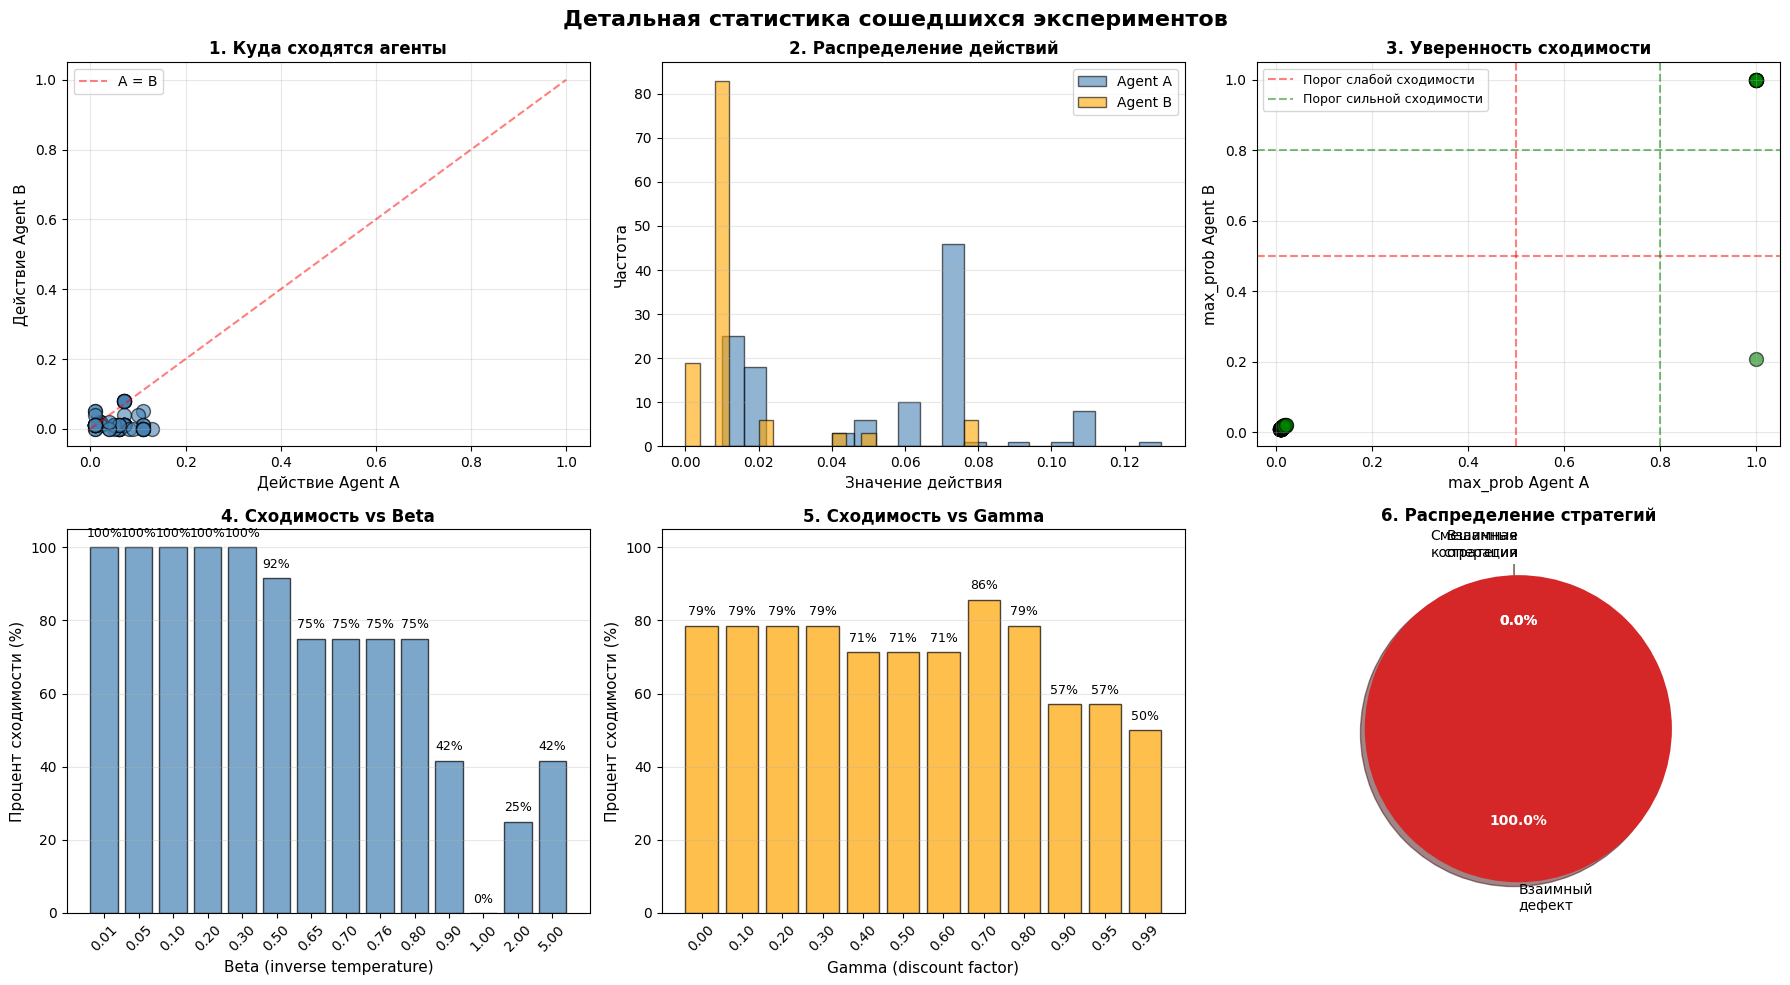


📊 Визуализация завершена для 120 сошедшихся экспериментов


In [71]:
# Визуализация статистик сошедшихся экспериментов
if len(converged_both) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Детальная статистика сошедшихся экспериментов', fontsize=16, fontweight='bold')
    
    # График 1: Распределение действий A vs B
    ax1 = axes[0, 0]
    ax1.scatter(actions_a, actions_b, alpha=0.6, s=100, c='steelblue', edgecolors='black')
    ax1.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='A = B')
    ax1.set_xlabel('Действие Agent A', fontsize=11)
    ax1.set_ylabel('Действие Agent B', fontsize=11)
    ax1.set_title('1. Куда сходятся агенты', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(-0.05, 1.05)
    ax1.set_ylim(-0.05, 1.05)
    
    # График 2: Гистограмма действий
    ax2 = axes[0, 1]
    ax2.hist(actions_a, bins=20, alpha=0.6, label='Agent A', color='steelblue', edgecolor='black')
    ax2.hist(actions_b, bins=20, alpha=0.6, label='Agent B', color='orange', edgecolor='black')
    ax2.set_xlabel('Значение действия', fontsize=11)
    ax2.set_ylabel('Частота', fontsize=11)
    ax2.set_title('2. Распределение действий', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # График 3: Уверенность сходимости (max_prob)
    ax3 = axes[0, 2]
    ax3.scatter(probs_a, probs_b, alpha=0.6, s=100, c='green', edgecolors='black')
    ax3.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Порог слабой сходимости')
    ax3.axvline(x=0.5, color='r', linestyle='--', alpha=0.5)
    ax3.axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='Порог сильной сходимости')
    ax3.axvline(x=0.8, color='g', linestyle='--', alpha=0.5)
    ax3.set_xlabel('max_prob Agent A', fontsize=11)
    ax3.set_ylabel('max_prob Agent B', fontsize=11)
    ax3.set_title('3. Уверенность сходимости', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=9)
    
    # График 4: Зависимость от Beta
    ax4 = axes[1, 0]
    betas_sorted = sorted(by_beta_conv.keys())
    percentages = [by_beta_conv[b][2] for b in betas_sorted]
    bars = ax4.bar(range(len(betas_sorted)), percentages, color='steelblue', edgecolor='black', alpha=0.7)
    ax4.set_xticks(range(len(betas_sorted)))
    ax4.set_xticklabels([f'{b:.2f}' for b in betas_sorted], rotation=45)
    ax4.set_xlabel('Beta (inverse temperature)', fontsize=11)
    ax4.set_ylabel('Процент сходимости (%)', fontsize=11)
    ax4.set_title('4. Сходимость vs Beta', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 105)
    
    # Добавляем значения на столбцы
    for i, (bar, pct) in enumerate(zip(bars, percentages)):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)
    
    # График 5: Зависимость от Gamma
    ax5 = axes[1, 1]
    gammas_sorted = sorted(by_gamma_conv.keys())
    percentages_gamma = [by_gamma_conv[g][2] for g in gammas_sorted]
    bars_gamma = ax5.bar(range(len(gammas_sorted)), percentages_gamma, color='orange', edgecolor='black', alpha=0.7)
    ax5.set_xticks(range(len(gammas_sorted)))
    ax5.set_xticklabels([f'{g:.2f}' for g in gammas_sorted], rotation=45)
    ax5.set_xlabel('Gamma (discount factor)', fontsize=11)
    ax5.set_ylabel('Процент сходимости (%)', fontsize=11)
    ax5.set_title('5. Сходимость vs Gamma', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_ylim(0, 105)
    
    # Добавляем значения на столбцы
    for i, (bar, pct) in enumerate(zip(bars_gamma, percentages_gamma)):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)
    
    # График 6: Кооперация vs Дефект (pie chart)
    ax6 = axes[1, 2]
    labels = ['Взаимная\nкооперация', 'Взаимный\nдефект', 'Смешанные\nстратегии']
    sizes = [both_coop, both_defect, mixed]
    colors = ['#2ca02c', '#d62728', '#ff7f0e']
    explode = (0.05, 0.05, 0.05)
    
    wedges, texts, autotexts = ax6.pie(sizes, explode=explode, labels=labels, colors=colors,
                                         autopct='%1.1f%%', shadow=True, startangle=90,
                                         textprops={'fontsize': 10})
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    ax6.set_title('6. Распределение стратегий', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Визуализация завершена для {len(converged_both)} сошедшихся экспериментов")
else:
    print("⚠️ Нет данных для визуализации")

## 4. Визуализация: Heat-map сходимости
- 🟢 Зелёный: сходимость к 0 (действие с индексом 0)
- 🔵 Синий: сходимость к другой точке
- 🔴 Красный: не сошлось (нестабильная политика)

In [72]:
# Визуализация 1: Совместная heat-map с аннотациями
# Показывает, куда именно сходятся оба агента
import importlib
import viz
importlib.reload(viz)
from viz import plot_joint_convergence_heatmap

# Путь для сохранения
joint_heatmap_path = output_dir / 'joint_convergence_heatmap.png'

plot_joint_convergence_heatmap(results, beta_values=beta_values, gamma_values=gamma_values,
                               title='Совместная сходимость агентов A и B\n(аннотации: A:значение, B:значение)',
                               save_path=str(joint_heatmap_path))

💾 График сохранён: /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/results/joint_convergence_heatmap.png


In [73]:
# Визуализация 2: Отдельные heat-map для A и B
# Показывает значения действий, к которым сходятся агенты
from viz import plot_action_value_heatmaps

# Путь для сохранения
action_heatmaps_path = output_dir / 'action_value_heatmaps.png'

plot_action_value_heatmaps(results, beta_values=beta_values, gamma_values=gamma_values,
                          save_path=str(action_heatmaps_path))

💾 График сохранён: /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/results/action_value_heatmaps.png


In [74]:
# Информация о сохранённых графиках
print("\n" + "="*60)
print("📊 ГРАФИКИ СХОДИМОСТИ СОХРАНЕНЫ")
print("="*60)
print(f"\n1️⃣ Совместная heat-map:")
print(f"   📁 {joint_heatmap_path}")
print(f"   📝 Показывает куда сходятся оба агента с цветовым кодированием")
print(f"   🟢 Зелёный = оба сошлись")
print(f"   🟡 Жёлтый = один сошёлся")
print(f"   🔴 Красный = оба не сошлись")

print(f"\n2️⃣ Отдельные heat-map для A и B:")
print(f"   📁 {action_heatmaps_path}")
print(f"   📝 Показывает значения действий, к которым сходятся агенты")
print(f"   📊 Два графика side-by-side (Agent A | Agent B)")

print(f"\n💡 Используйте эти графики для:")
print(f"   • Анализа зависимости сходимости от beta и gamma")
print(f"   • Поиска оптимальных параметров")
print(f"   • Презентации результатов")
print(f"   • Сравнения разных экспериментов")
print("="*60)


📊 ГРАФИКИ СХОДИМОСТИ СОХРАНЕНЫ

1️⃣ Совместная heat-map:
   📁 /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/results/joint_convergence_heatmap.png
   📝 Показывает куда сходятся оба агента с цветовым кодированием
   🟢 Зелёный = оба сошлись
   🟡 Жёлтый = один сошёлся
   🔴 Красный = оба не сошлись

2️⃣ Отдельные heat-map для A и B:
   📁 /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/results/action_value_heatmaps.png
   📝 Показывает значения действий, к которым сходятся агенты
   📊 Два графика side-by-side (Agent A | Agent B)

💡 Используйте эти графики для:
   • Анализа зависимости сходимости от beta и gamma
   • Поиска оптимальных параметров
   • Презентации результатов
   • Сравнения разных экспериментов


🔍 Анализ совместной стратегии:
Из 120 случаев, где оба сошлись:
  - Сходятся к одинаковому действию: 31 (25.8%)
  - Сходятся к разным действиям:    89 (74.2%)


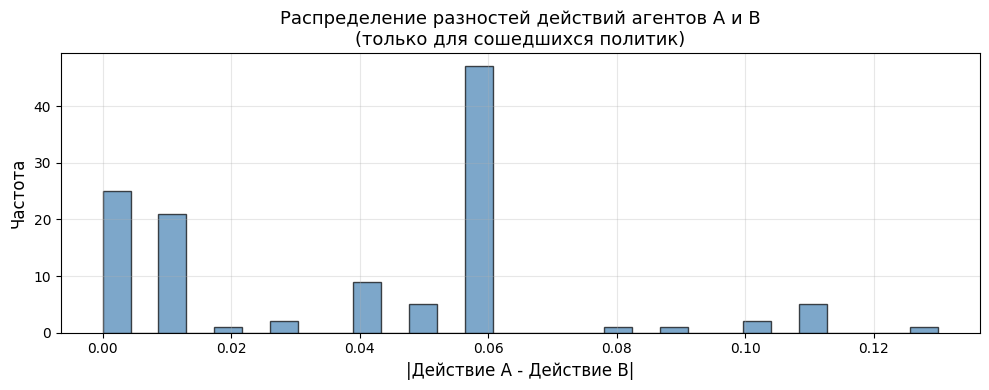

In [75]:
# Визуализация 3: Анализ совместной стратегии
# Показывает, насколько часто агенты сходятся к одинаковым действиям
same_action_count = 0
total_converged = 0

for r in results:
    if r['conv_a']['converged'] and r['conv_b']['converged']:
        total_converged += 1
        val_a = r['conv_a']['argmax_value']
        val_b = r['conv_b']['argmax_value']
        # Считаем "одинаковыми", если разница < 0.01
        if abs(val_a - val_b) < 0.01:
            same_action_count += 1

if total_converged > 0:
    pct_same = 100 * same_action_count / total_converged
    print(f"🔍 Анализ совместной стратегии:")
    print(f"Из {total_converged} случаев, где оба сошлись:")
    print(f"  - Сходятся к одинаковому действию: {same_action_count} ({pct_same:.1f}%)")
    print(f"  - Сходятся к разным действиям:    {total_converged - same_action_count} ({100-pct_same:.1f}%)")
    
    # Распределение разностей
    diffs = []
    for r in results:
        if r['conv_a']['converged'] and r['conv_b']['converged']:
            diff = abs(r['conv_a']['argmax_value'] - r['conv_b']['argmax_value'])
            diffs.append(diff)
    
    if diffs:
        plt.figure(figsize=(10, 4))
        plt.hist(diffs, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        plt.xlabel('|Действие A - Действие B|', fontsize=12)
        plt.ylabel('Частота', fontsize=12)
        plt.title('Распределение разностей действий агентов A и B\n(только для сошедшихся политик)', fontsize=13)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("⚠️ Нет случаев, где оба агента сошлись")

## 5. Загрузка результатов из файла (опционально)
Если grid search уже был выполнен ранее, можно загрузить результаты из JSON.

## 4. Детальная визуализация несошедшихся экспериментов

Создадим комплексные графики (как в `run_experiment.py`) для всех красных блоков на heatmap.

In [76]:
from pathlib import Path
from viz import plot_comprehensive_results

# Директория для сохранения визуализаций несошедшихся экспериментов
non_conv_dir = Path('../results/non-conv')
non_conv_dir.mkdir(parents=True, exist_ok=True)

# Находим все несошедшиеся эксперименты (красные блоки)
non_converged = []
for r in results:
    conv_a = r['conv_a']
    conv_b = r['conv_b']
    
    # Если хотя бы один агент не сошёлся
    if not conv_a['converged'] or not conv_b['converged']:
        non_converged.append(r)

print(f"📊 Найдено несошедшихся экспериментов: {len(non_converged)}/{len(results)}")
print(f"💾 Результаты будут сохранены в: {non_conv_dir.absolute()}")

# Предлагаем выбор: создать все или только первые N
max_to_create = 5  # Ограничение для предотвращения создания слишком большого количества графиков

if len(non_converged) > max_to_create:
    print(f"\n⚠️ Слишком много несошедшихся экспериментов!")
    print(f"Создаём детальные графики только для первых {max_to_create}.")
    print(f"Измените max_to_create для создания большего количества.")
    to_visualize = non_converged[:max_to_create]
else:
    to_visualize = non_converged

print(f"\n🎨 Создаём визуализации для {len(to_visualize)} экспериментов...")
print("(это может занять некоторое время)\n")

📊 Найдено несошедшихся экспериментов: 48/168
💾 Результаты будут сохранены в: /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/notebooks/../results/non-conv

⚠️ Слишком много несошедшихся экспериментов!
Создаём детальные графики только для первых 5.
Измените max_to_create для создания большего количества.

🎨 Создаём визуализации для 5 экспериментов...
(это может занять некоторое время)



In [77]:
# Функция для запуска полного эксперимента с сохранением всех данных
def run_full_experiment(beta: float, gamma: float,
                        params: PayoffParams,
                        n: int = 20,
                        steps: int = 3000,
                        alpha: float = 0.01,
                        init_mode: str = 'uniform',
                        seed: int = 43):
    """Запускает полный эксперимент и возвращает все данные для визуализации."""
    game = ContinuousBimatrixGame(params, n=n)
    agent_a = SoftmaxSARSAAgent(game.num_actions(), alpha=alpha, gamma=gamma,
                                beta=beta, init_mode=init_mode, seed=seed)
    agent_b = SoftmaxSARSAAgent(game.num_actions(), alpha=alpha, gamma=gamma,
                                beta=beta, init_mode=init_mode, seed=seed + 1)
    
    policies_a = []
    policies_b = []
    rewards_a = []
    rewards_b = []
    q_values_a = []
    q_values_b = []
    
    a = agent_a.start_episode()
    b = agent_b.start_episode()
    
    for _ in range(steps):
        r_a = game.payoff_player0(a, b)
        r_b = game.payoff_player1(a, b)
        next_a = agent_a.choose_action()
        next_b = agent_b.choose_action()
        agent_a.step(r_a, next_action=next_a)
        agent_b.step(r_b, next_action=next_b)
        
        policies_a.append(agent_a.get_action_probs())
        policies_b.append(agent_b.get_action_probs())
        rewards_a.append(r_a)
        rewards_b.append(r_b)
        q_values_a.append(agent_a.Q[0].copy())
        q_values_b.append(agent_b.Q[0].copy())
        
        a, b = next_a, next_b
    
    return {
        'rewards_a': rewards_a,
        'rewards_b': rewards_b,
        'q_values_a': q_values_a,
        'q_values_b': q_values_b,
        'policies_a': policies_a,
        'policies_b': policies_b,
        'action_values': game.grid()
    }

Создание визуализаций:   0%|          | 0/5 [00:00<?, ?it/s]


[1/5] β=0.5, γ=0.99


Создание визуализаций:  20%|██        | 1/5 [00:08<00:33,  8.47s/it]

График сохранен в: ../results/non-conv/beta0.5_gamma0.99_non-converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 1.8182 ± 0.8909
Средняя награда Agent B: 1.8356 ± 0.8902

Последние 100 шагов:
  Agent A: 1.6425
  Agent B: 1.7301

Финальные Q-значения:
  Agent A: min=5.876, max=10.700, mean=8.762
  Agent B: min=5.758, max=10.919, mean=8.847

Финальное распределение политик:
  Agent A: энтропия=4.473
  Agent B: энтропия=4.450
  Agent A: макс. вероятность=0.022 (действие 0.020)
  Agent B: макс. вероятность=0.023 (действие 0.040)

  ✅ Сохранено: beta0.5_gamma0.99_non-converged.png

[2/5] β=0.65, γ=0.9


Создание визуализаций:  40%|████      | 2/5 [00:16<00:25,  8.35s/it]

...

График сохранен в: ../results/non-conv/beta0.65_gamma0.95_non-converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 1.7354 ± 0.8562
Средняя награда Agent B: 1.7451 ± 0.8524

Последние 100 шагов:
  Agent A: 1.5282
  Agent B: 1.6018

Финальные Q-значения:
  Agent A: min=4.096, max=9.710, mean=7.446
  Agent B: min=3.657, max=9.732, mean=7.498

Финальное распределение политик:
  Agent A: энтропия=4.282
  Agent B: энтропия=4.278
  Agent A: макс. вероятность=0.027 (действие 0.010)
  Agent B: макс. вероятность=0.026 (действие 0.000)

  ✅ Сохранено: beta0.65_gamma0.95_non-converged.png

[4/5] β=0.65, γ=0.99


Создание визуализаций:  80%|████████  | 4/5 [00:33<00:08,  8.38s/it]

График сохранен в: ../results/non-conv/beta0.65_gamma0.99_non-converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 1.6991 ± 0.8379
Средняя награда Agent B: 1.7097 ± 0.8311

Последние 100 шагов:
  Agent A: 1.4157
  Agent B: 1.5129

Финальные Q-значения:
  Agent A: min=3.667, max=11.333, mean=8.159
  Agent B: min=3.574, max=11.524, mean=8.212

Финальное распределение политик:
  Agent A: энтропия=4.090
  Agent B: энтропия=4.061
  Agent A: макс. вероятность=0.034 (действие 0.010)
  Agent B: макс. вероятность=0.034 (действие 0.000)

  ✅ Сохранено: beta0.65_gamma0.99_non-converged.png

[5/5] β=0.7, γ=0.9


Создание визуализаций: 100%|██████████| 5/5 [00:42<00:00,  8.48s/it]

График сохранен в: ../results/non-conv/beta0.7_gamma0.9_non-converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 1.7431 ± 0.8580
Средняя награда Agent B: 1.7447 ± 0.8531

Последние 100 шагов:
  Agent A: 1.5832
  Agent B: 1.6400

Финальные Q-значения:
  Agent A: min=3.951, max=8.305, mean=6.551
  Agent B: min=3.099, max=8.254, mean=6.576

Финальное распределение политик:
  Agent A: энтропия=4.361
  Agent B: энтропия=4.360
  Agent A: макс. вероятность=0.024 (действие 0.080)
  Agent B: макс. вероятность=0.023 (действие 0.000)

  ✅ Сохранено: beta0.7_gamma0.9_non-converged.png

✨ Готово! Создано 5 визуализаций в /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/notebooks/../results/non-conv


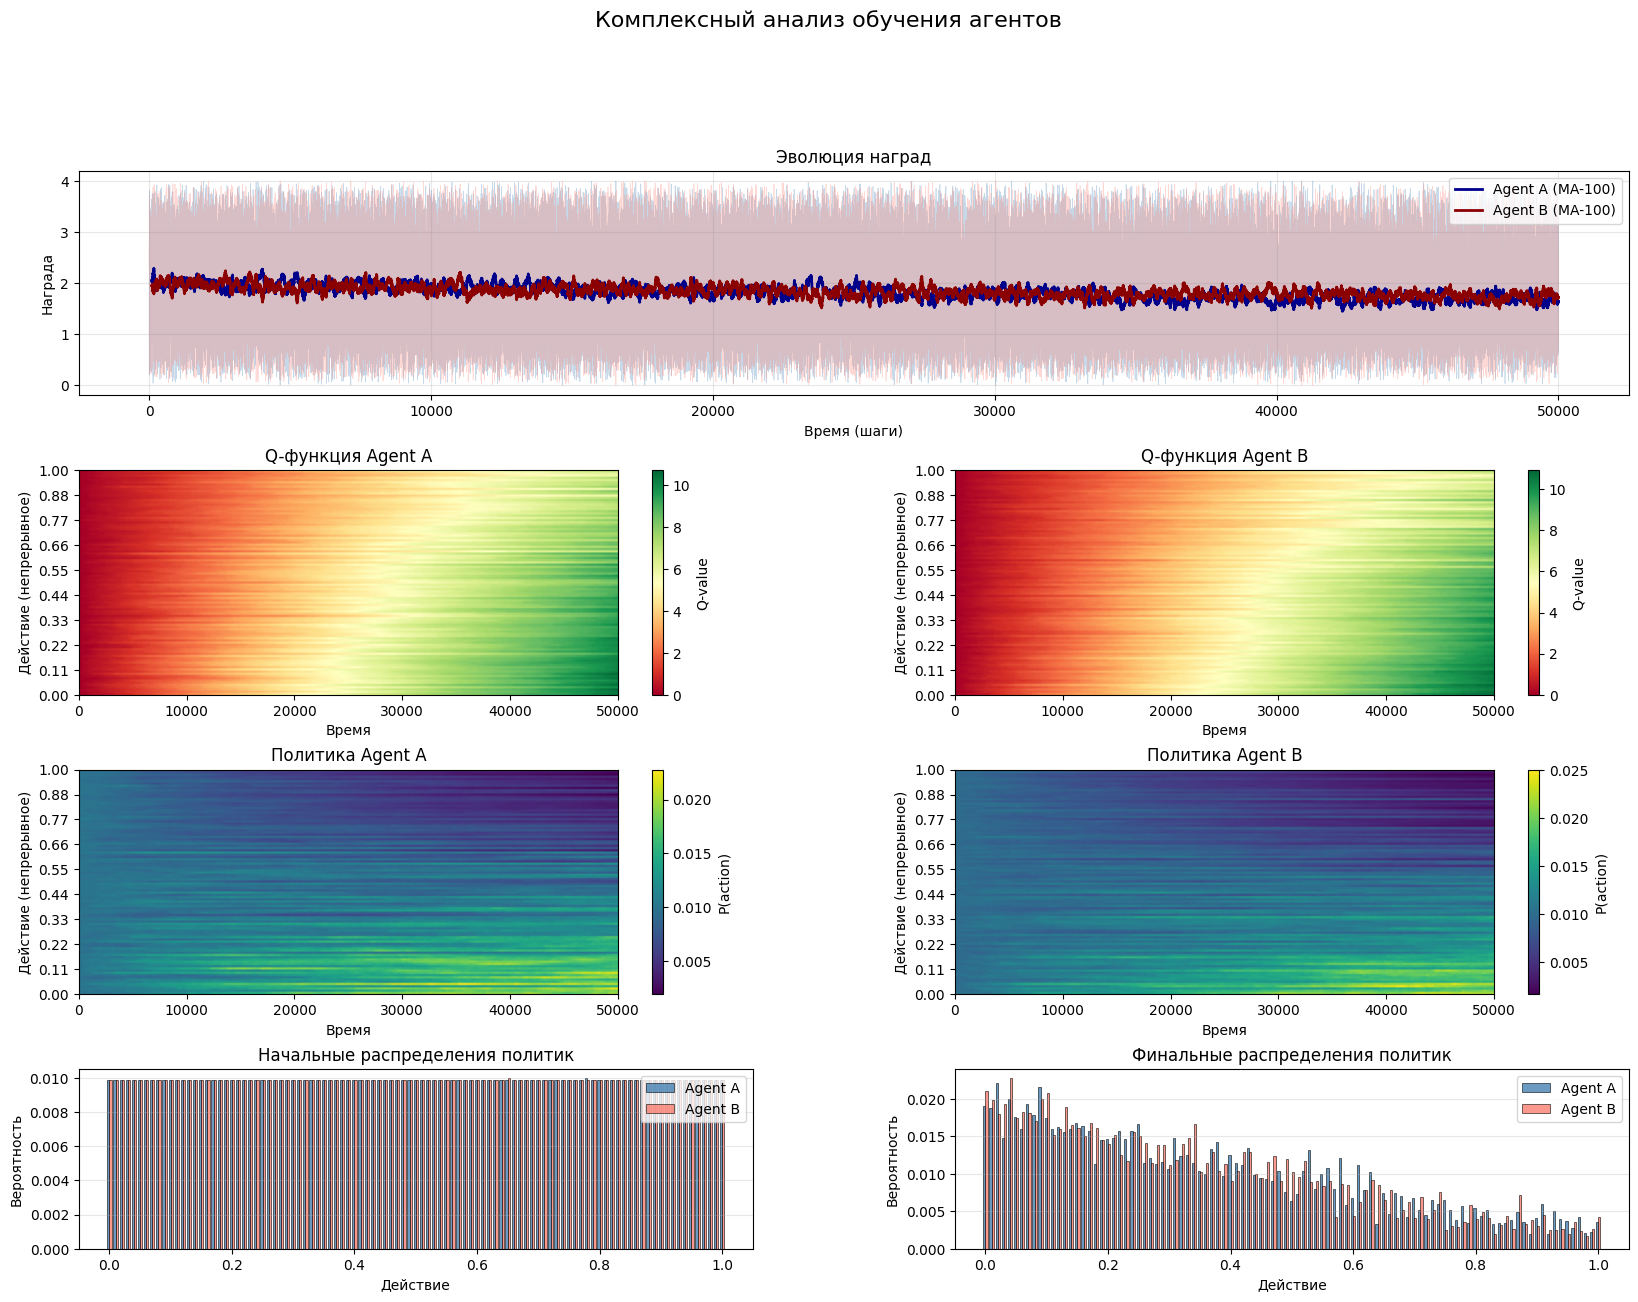

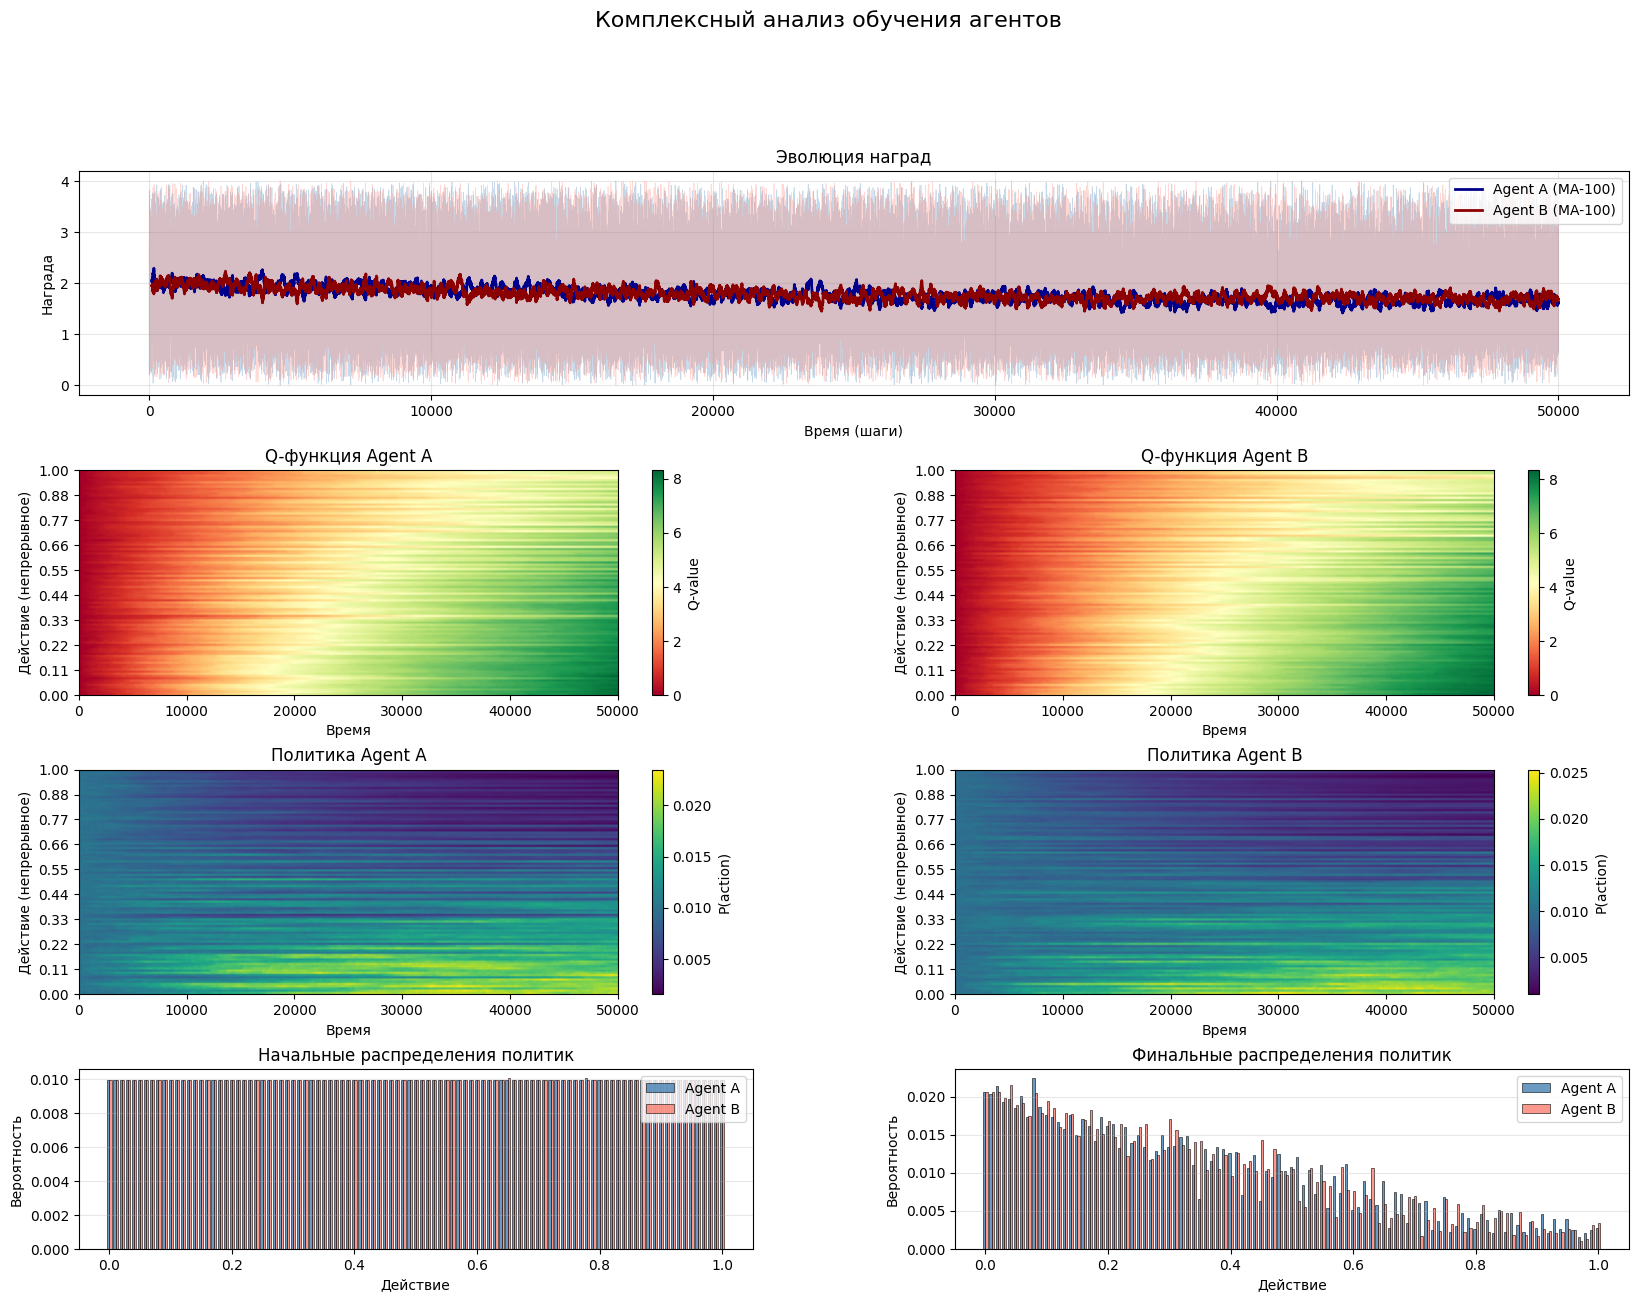

In [ ]:
# Создаём визуализации для несошедшихся экспериментов
# Используем обычный tqdm (без notebook виджетов)
from tqdm import tqdm as tqdm_bar

for i, exp in enumerate(tqdm_bar(to_visualize, desc="Создание визуализаций")):
    beta = exp['beta']
    gamma = exp['gamma']
    
    # Формируем имя файла
    filename = f"beta{beta}_gamma{gamma}_non-converged.png"
    save_path = non_conv_dir / filename
    
    print(f"\n[{i+1}/{len(to_visualize)}] β={beta}, γ={gamma}")
    
    # Запускаем полный эксперимент для получения всех данных
    data = run_full_experiment(
        beta=beta,
        gamma=gamma,
        params=params,
        n=n,
        steps=steps,
        alpha=alpha,
        init_mode=init_mode,
        seed=seed
    )
    
    # Создаём комплексную визуализацию (как в run_experiment.py)
    plot_comprehensive_results(
        rewards_a=data['rewards_a'],
        rewards_b=data['rewards_b'],
        q_values_a=data['q_values_a'],
        q_values_b=data['q_values_b'],
        policies_a=data['policies_a'],
        policies_b=data['policies_b'],
        action_values=data['action_values'],
        window_size=100,
        save_path=str(save_path)
    )
    
    print(f"  ✅ Сохранено: {filename}")

print(f"\n✨ Готово! Создано {len(to_visualize)} визуализаций в {non_conv_dir.absolute()}")

### Опционально: Создать визуализации для ВСЕХ несошедшихся

Раскомментируйте ячейку ниже, если хотите создать графики для всех несошедшихся экспериментов (может занять много времени!).

In [ ]:
# # РАСКОММЕНТИРУЙТЕ, ЧТОБЫ СОЗДАТЬ ВСЕ ВИЗУАЛИЗАЦИИ
# from tqdm import tqdm as tqdm_bar

# print(f"🚀 Создаём визуализации для ВСЕХ {len(non_converged)} несошедшихся экспериментов...")
# print("⏱️ Это может занять несколько минут...\n")

# for i, exp in enumerate(tqdm_bar(non_converged, desc="Полная визуализация")):
#     beta = exp['beta']
#     gamma = exp['gamma']
#     filename = f"beta{beta}_gamma{gamma}_non-converged.png"
#     save_path = non_conv_dir / filename
    
#     # Пропускаем, если файл уже существует
#     if save_path.exists():
#         continue
    
#     data = run_full_experiment(beta=beta, gamma=gamma, params=params,
#                                n=n, steps=steps, alpha=alpha,
#                                init_mode=init_mode, seed=seed)
    
#     plot_comprehensive_results(
#         rewards_a=data['rewards_a'], rewards_b=data['rewards_b'],
#         q_values_a=data['q_values_a'], q_values_b=data['q_values_b'],
#         policies_a=data['policies_a'], policies_b=data['policies_b'],
#         action_values=data['action_values'], window_size=100,
#         save_path=str(save_path)
#     )

# print(f"\n✨ Готово! Все визуализации в {non_conv_dir.absolute()}")

In [ ]:
# Загрузка результатов из сохранённого файла
# with open(output_file, 'r', encoding='utf-8') as f:
#     data = json.load(f)
#     loaded_results = data['results']
#     loaded_params = data['params']
# 
# plot_convergence_heatmap(loaded_results,
#                         beta_values=loaded_params['beta_values'],
#                         gamma_values=loaded_params['gamma_values'],
#                         title='Карта сходимости (загружено из файла)')

## 6. Визуализация сошедшихся экспериментов

Создадим детальные графики для 10 успешно сошедшихся экспериментов.

In [ ]:
# Создаём папку для сохранения визуализаций сошедшихся экспериментов
conv_dir = Path('../results/conv')
conv_dir.mkdir(parents=True, exist_ok=True)

# Находим все сошедшиеся эксперименты (оба агента)
converged_experiments = []
for r in results:
    if r['conv_a']['converged'] and r['conv_b']['converged']:
        converged_experiments.append(r)

print(f"✅ Найдено сошедшихся экспериментов: {len(converged_experiments)}/{len(results)}")
print(f"💾 Результаты будут сохранены в: {conv_dir.absolute()}")

# Выбираем последние 20
num_to_visualize = min(20, len(converged_experiments))
converged_to_visualize = converged_experiments[-num_to_visualize:]

print(f"\n🎨 Создаём визуализации для {num_to_visualize} сошедшихся экспериментов...")


✅ Найдено сошедшихся экспериментов: 120/168
💾 Результаты будут сохранены в: /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/notebooks/../results/conv

🎨 Создаём визуализации для 10 сошедшихся экспериментов...


Создание визуализаций:   0%|          | 0/10 [00:00<?, ?it/s]


[1/10] β=0.9, γ=0.3
  Действие A: 0.010 (p=0.016)
  Действие B: 0.010 (p=0.017)


Создание визуализаций:  10%|█         | 1/10 [00:08<01:18,  8.76s/it]

График сохранен в: ../results/conv/beta0.9_gamma0.3_converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 1.8261 ± 0.8987
Средняя награда Agent B: 1.8318 ± 0.8975

Последние 100 шагов:
  Agent A: 1.7772
  Agent B: 1.8164

Финальные Q-значения:
  Agent A: min=1.721, max=3.024, mean=2.385
  Agent B: min=1.680, max=3.105, mean=2.399

Финальное распределение политик:
  Agent A: энтропия=4.566
  Agent B: энтропия=4.567
  Agent A: макс. вероятность=0.017 (действие 0.060)
  Agent B: макс. вероятность=0.018 (действие 0.010)

  ✅ Сохранено: beta0.9_gamma0.3_converged.png

[2/10] β=0.9, γ=0.7
  Действие A: 0.090 (p=0.021)
  Действие B: 0.000 (p=0.021)


Создание визуализаций:  20%|██        | 2/10 [00:17<01:12,  9.03s/it]

...

График сохранен в: ../results/conv/beta5.0_gamma0.9_converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 0.9193 ± 0.2309
Средняя награда Agent B: 1.3371 ± 0.1543

Последние 100 шагов:
  Agent A: 0.8900
  Agent B: 1.3300

Финальные Q-значения:
  Agent A: min=0.000, max=8.900, mean=0.252
  Agent B: min=0.037, max=13.300, mean=0.337

Финальное распределение политик:
  Agent A: энтропия=-0.000
  Agent B: энтропия=-0.000
  Agent A: макс. вероятность=1.000 (действие 0.110)
  Agent B: макс. вероятность=1.000 (действие 0.000)

  ✅ Сохранено: beta5.0_gamma0.9_converged.png

[9/10] β=5.0, γ=0.95
  Действие A: 0.110 (p=1.000)
  Действие B: 0.000 (p=1.000)


Создание визуализаций:  90%|█████████ | 9/10 [01:09<00:07,  7.34s/it]

График сохранен в: ../results/conv/beta5.0_gamma0.95_converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 0.9192 ± 0.2303
Средняя награда Agent B: 1.3372 ± 0.1542

Последние 100 шагов:
  Agent A: 0.8900
  Agent B: 1.3300

Финальные Q-значения:
  Agent A: min=0.000, max=17.800, mean=0.341
  Agent B: min=0.042, max=26.600, mean=0.469

Финальное распределение политик:
  Agent A: энтропия=-0.000
  Agent B: энтропия=-0.000
  Agent A: макс. вероятность=1.000 (действие 0.110)
  Agent B: макс. вероятность=1.000 (действие 0.000)

  ✅ Сохранено: beta5.0_gamma0.95_converged.png

[10/10] β=5.0, γ=0.99
  Действие A: 0.110 (p=1.000)
  Действие B: 0.000 (p=1.000)


Создание визуализаций: 100%|██████████| 10/10 [01:16<00:00,  7.61s/it]

График сохранен в: ../results/conv/beta5.0_gamma0.99_converged.png

СТАТИСТИКА ОБУЧЕНИЯ
Средняя награда Agent A: 0.9192 ± 0.2303
Средняя награда Agent B: 1.3372 ± 0.1541

Последние 100 шагов:
  Agent A: 0.8900
  Agent B: 1.3300

Финальные Q-значения:
  Agent A: min=0.014, max=88.389, mean=1.040
  Agent B: min=0.038, max=131.980, mean=1.513

Финальное распределение политик:
  Agent A: энтропия=-0.000
  Agent B: энтропия=-0.000
  Agent A: макс. вероятность=1.000 (действие 0.110)
  Agent B: макс. вероятность=1.000 (действие 0.000)

  ✅ Сохранено: beta5.0_gamma0.99_converged.png

✨ Готово! Создано 10 визуализаций в /Users/macbook/Documents/learning/rl-projects/TheoryGamesDL/experiments/exp4/notebooks/../results/conv


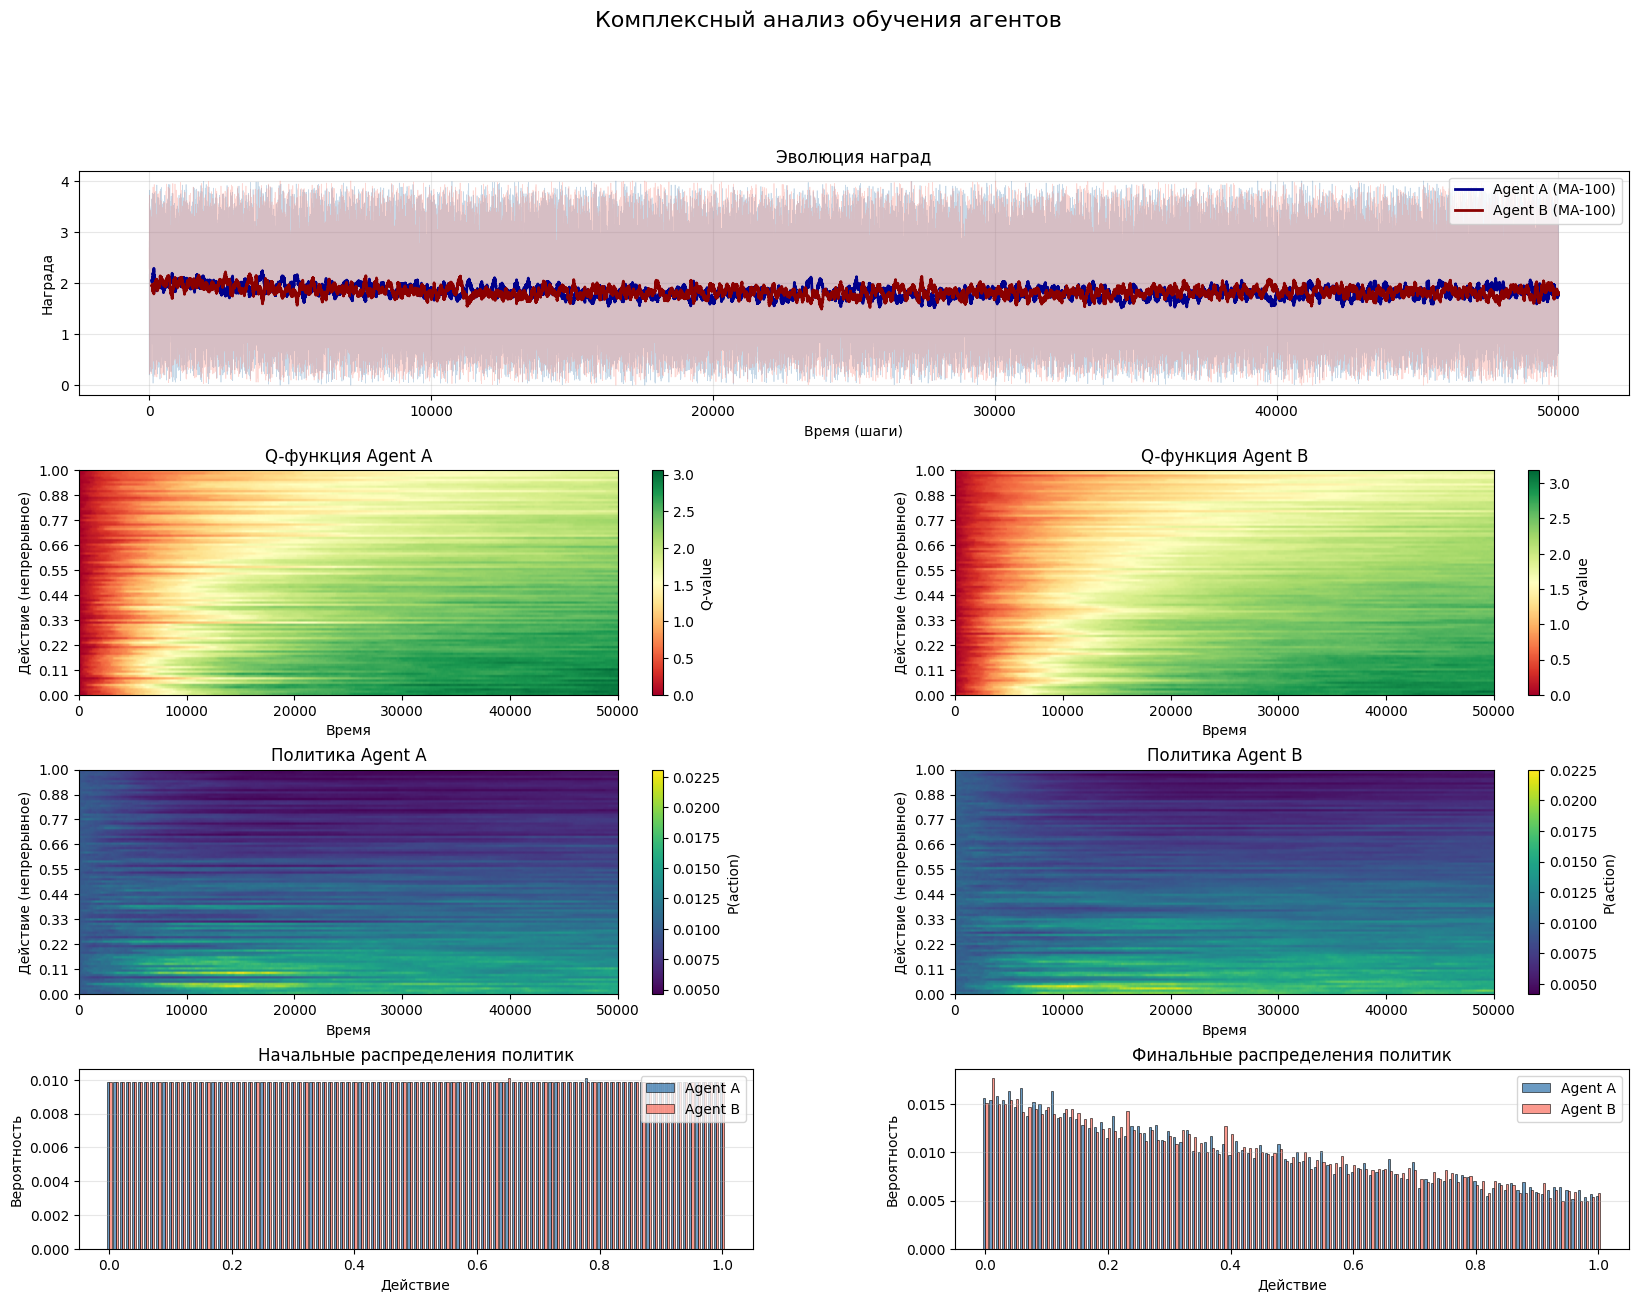

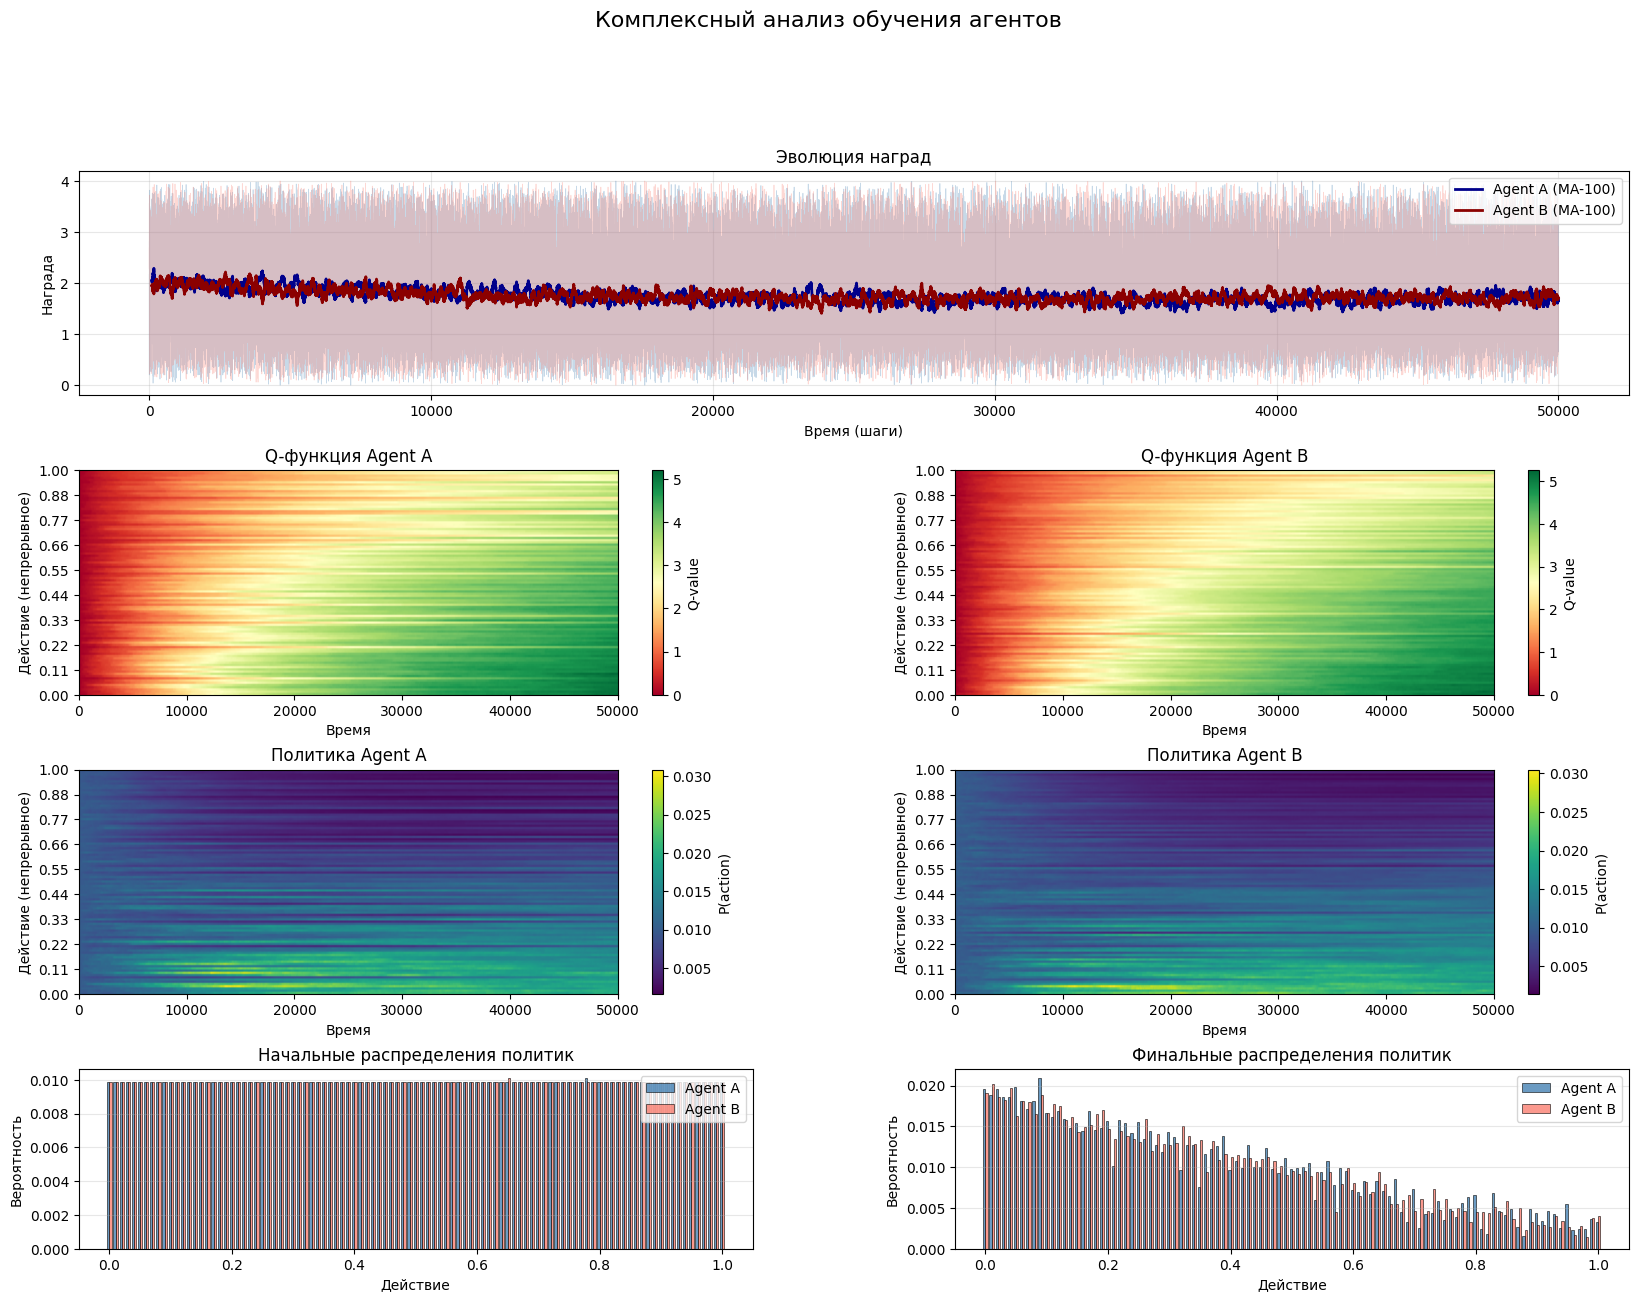

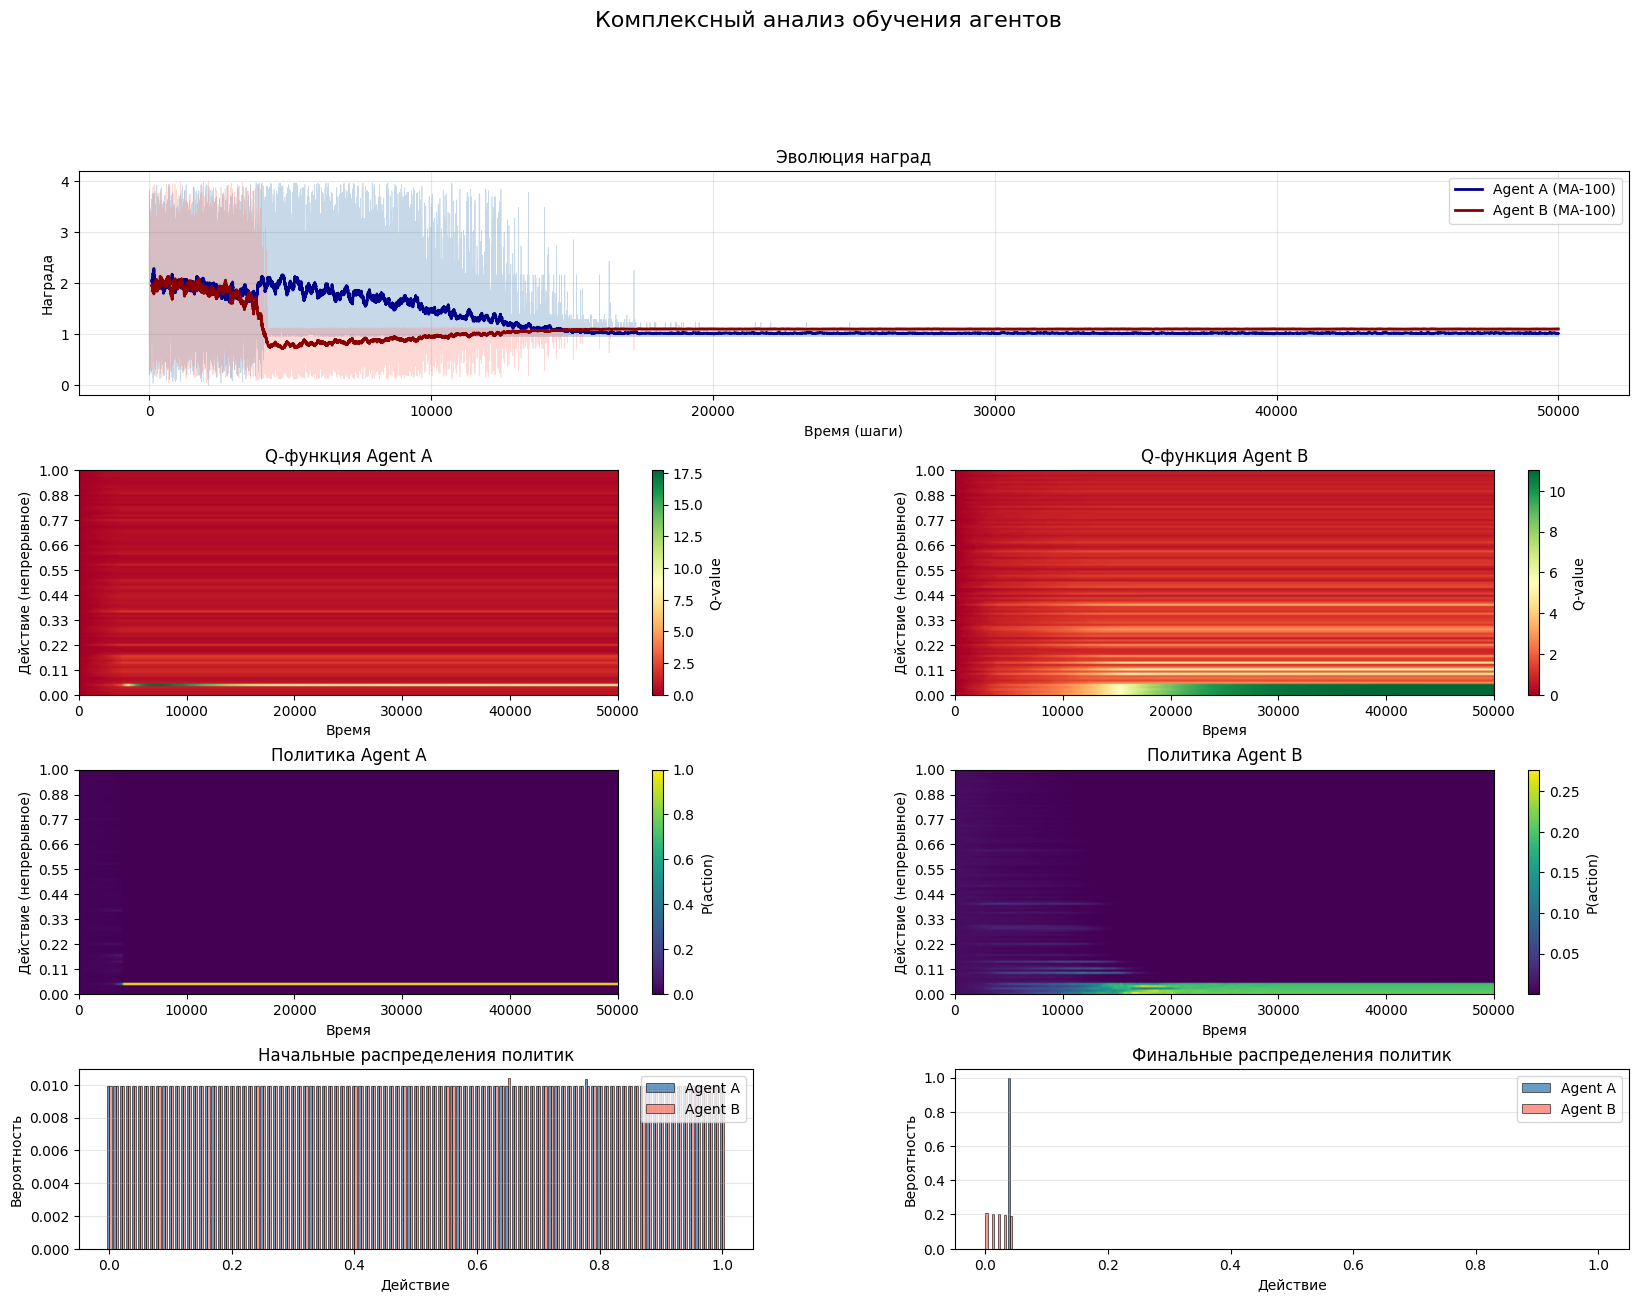

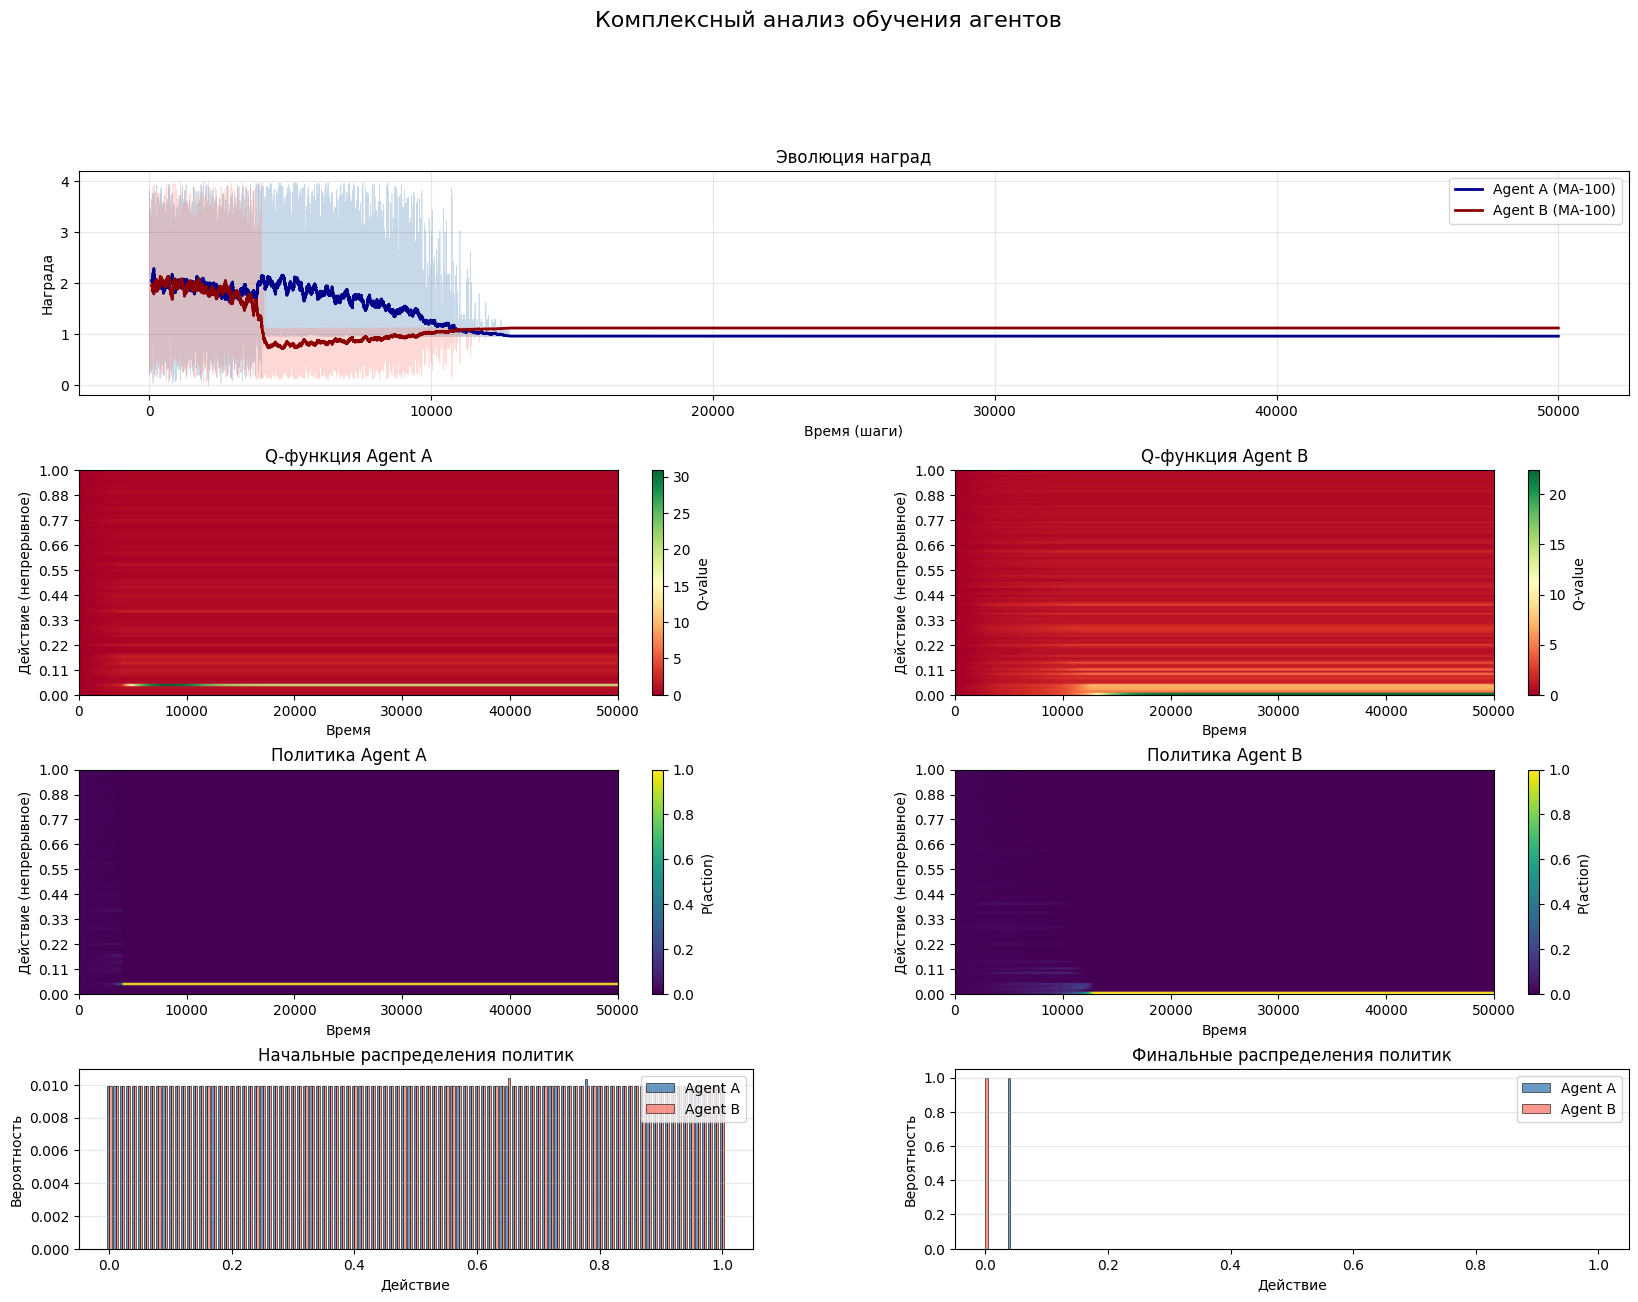

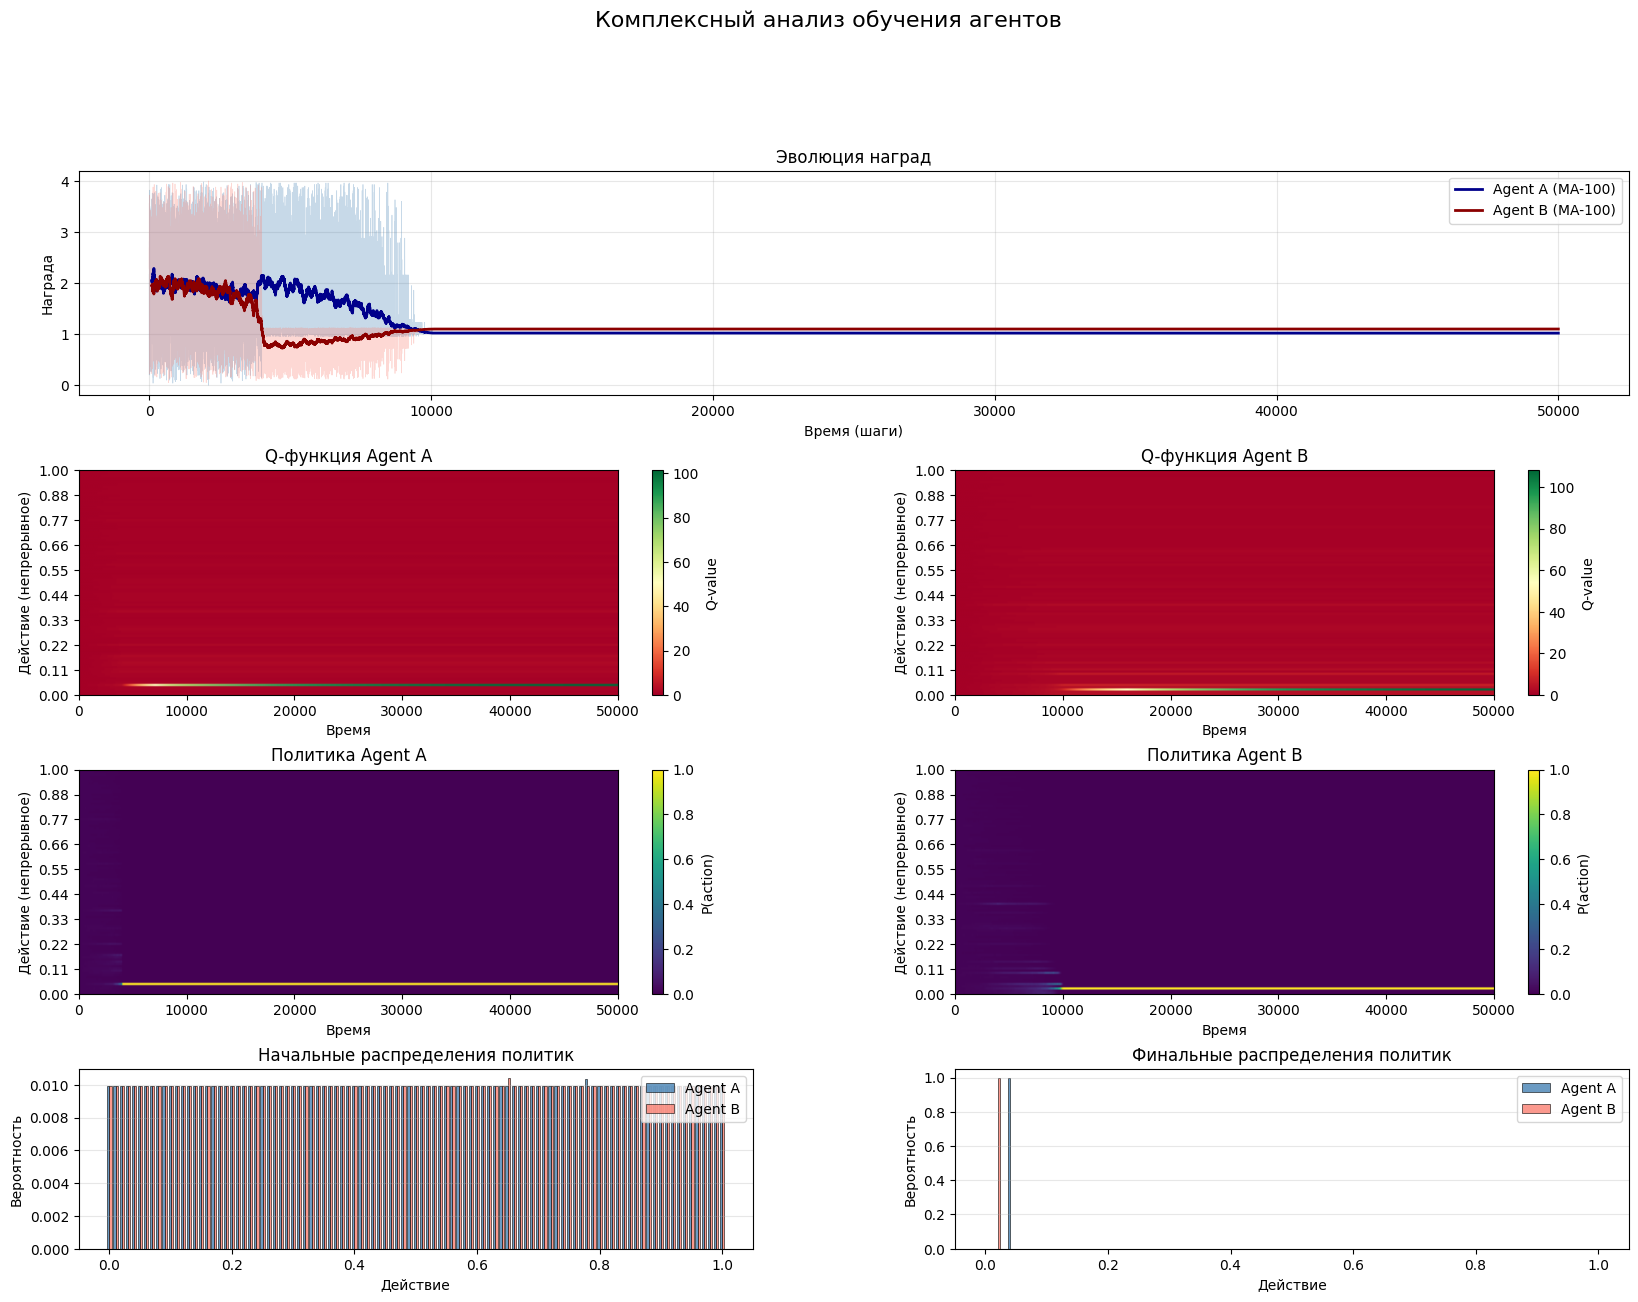

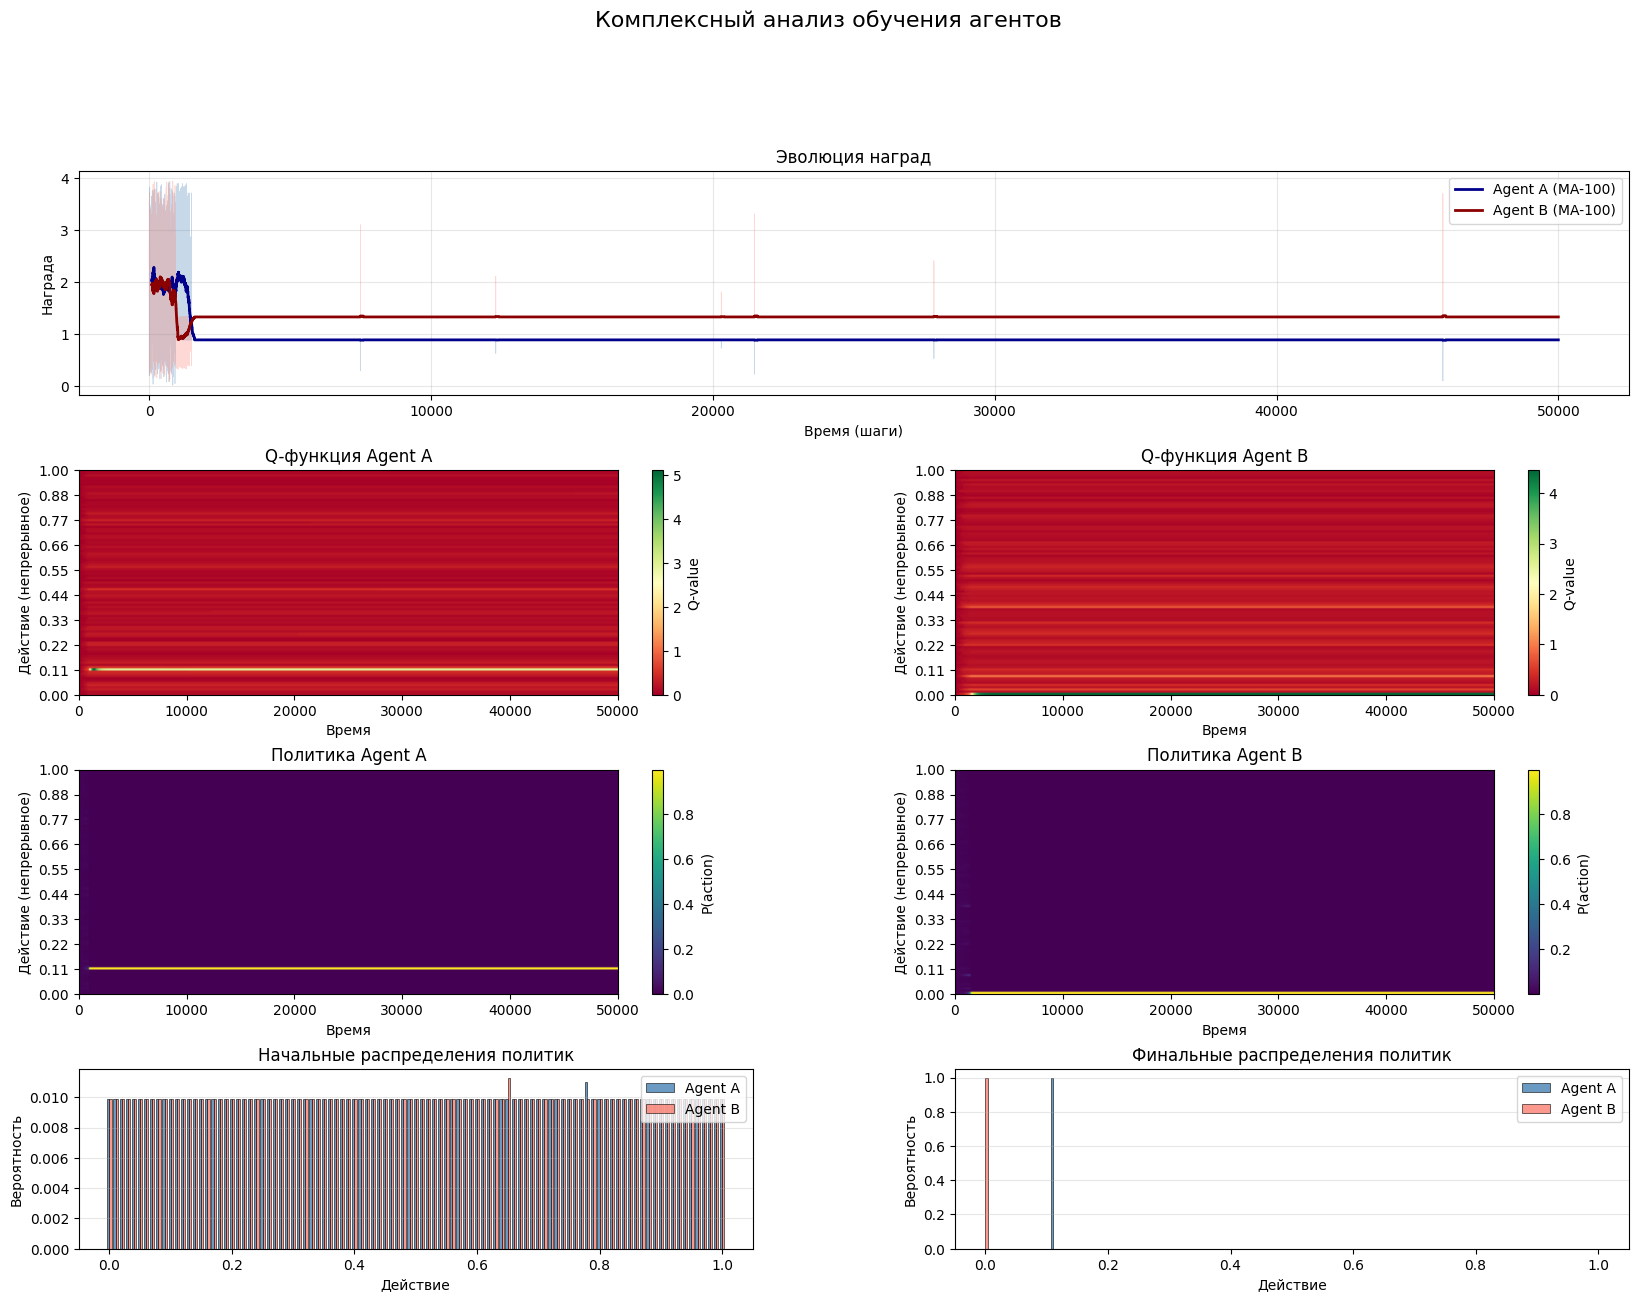

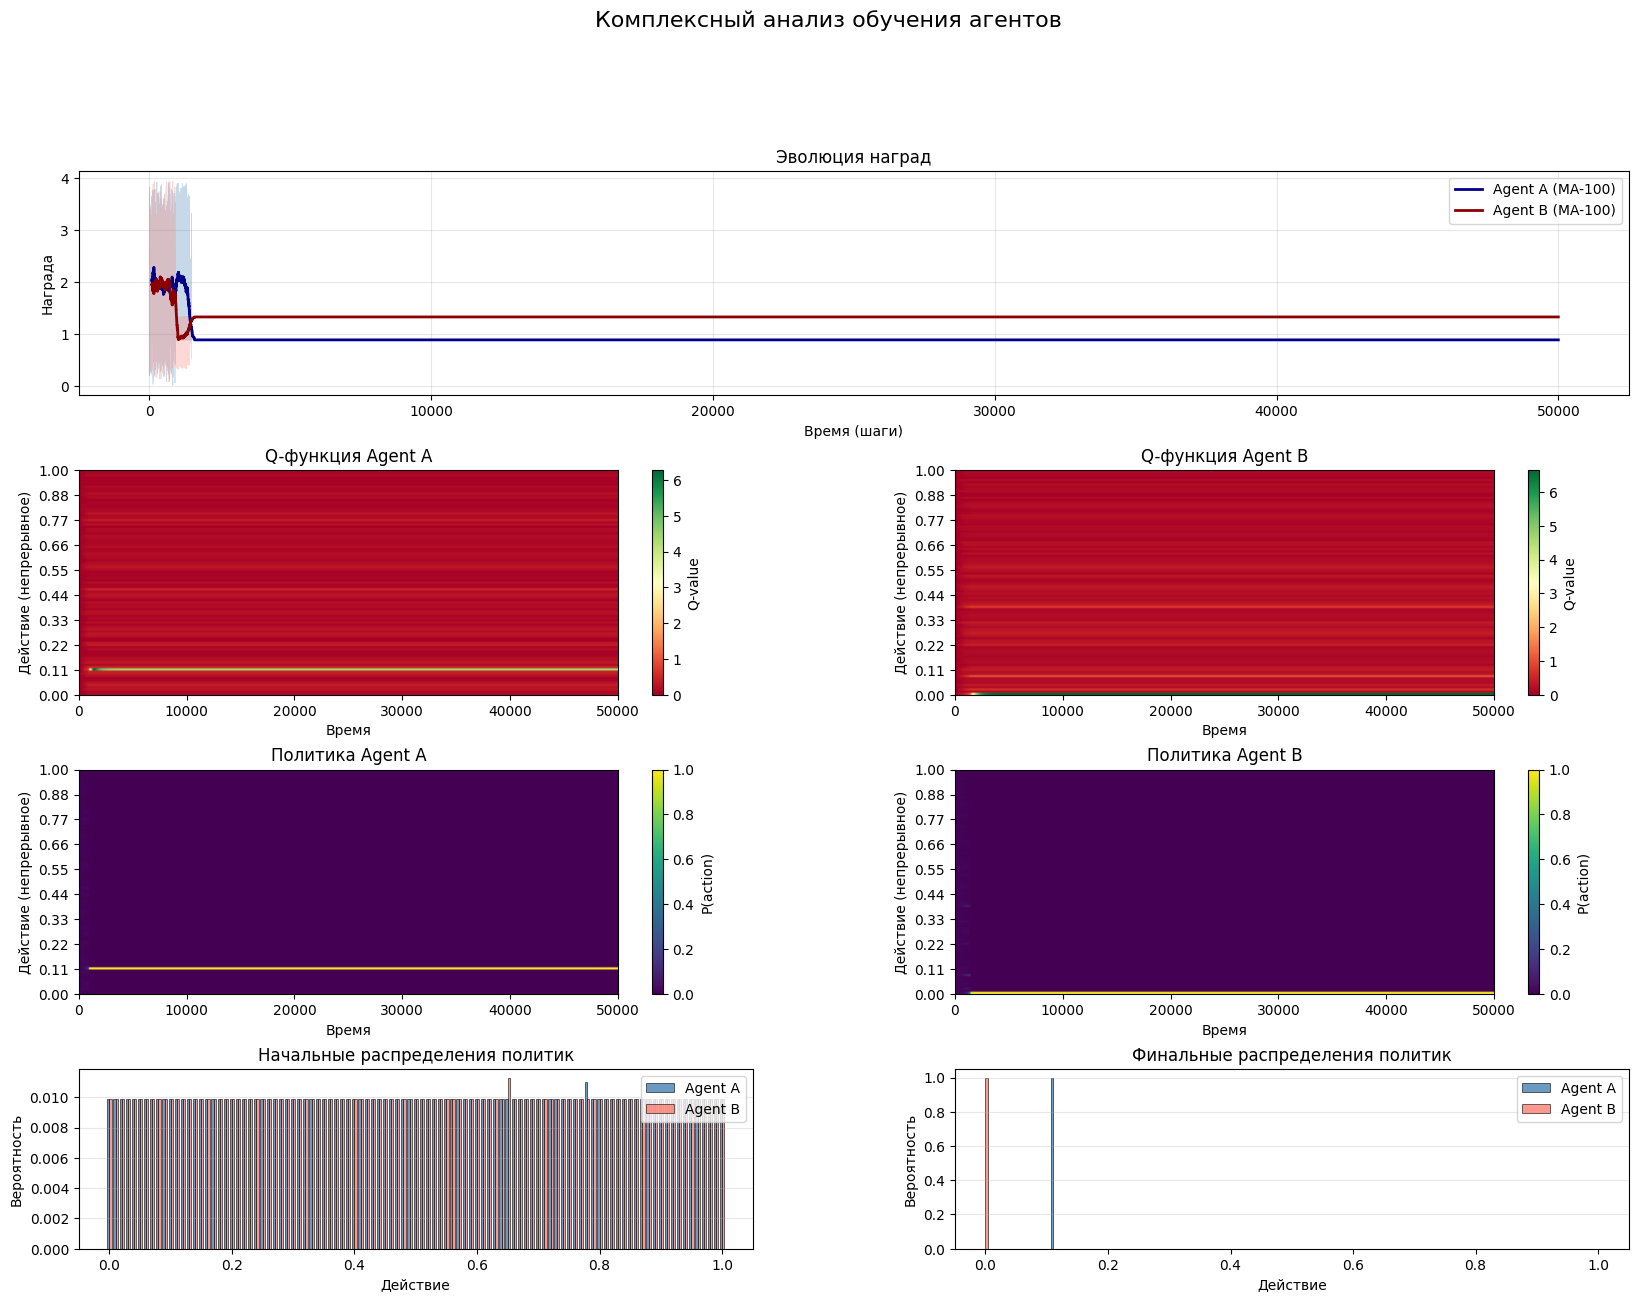

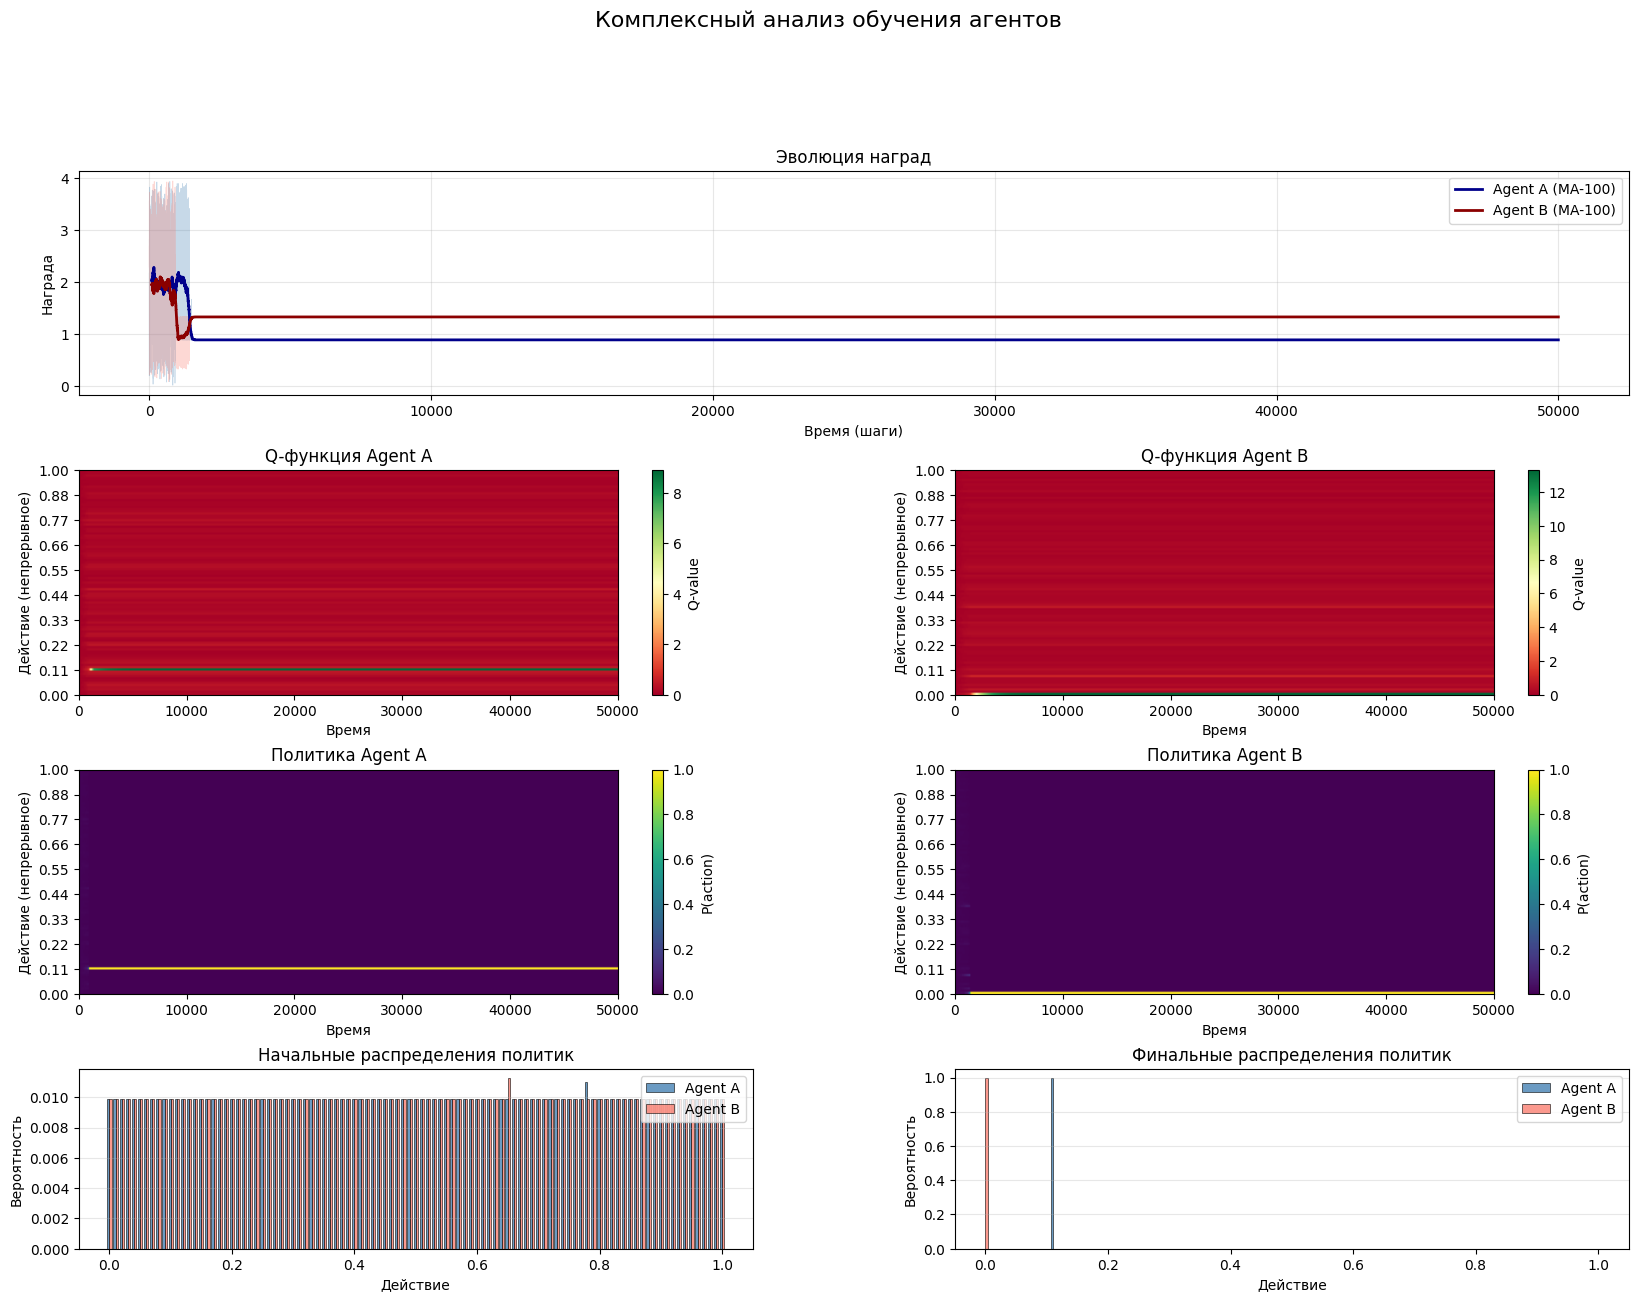

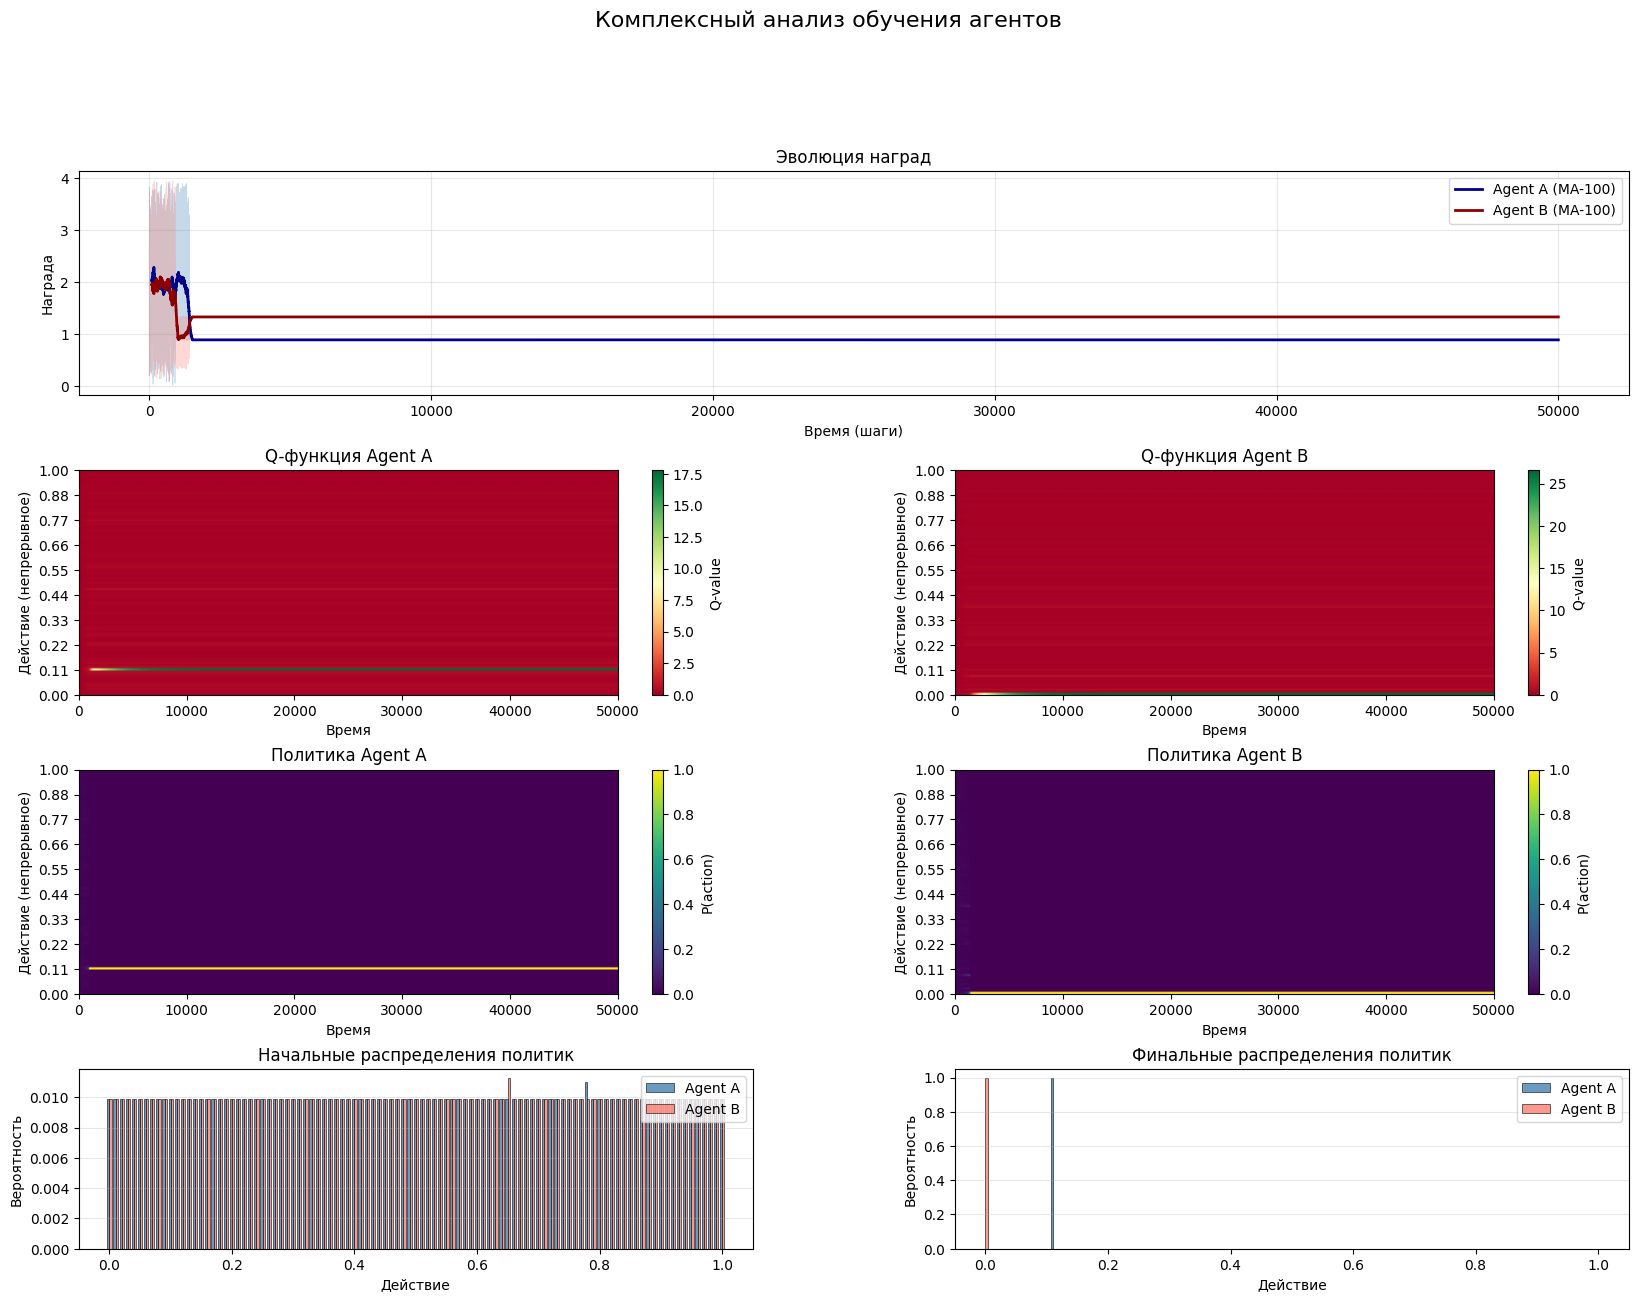

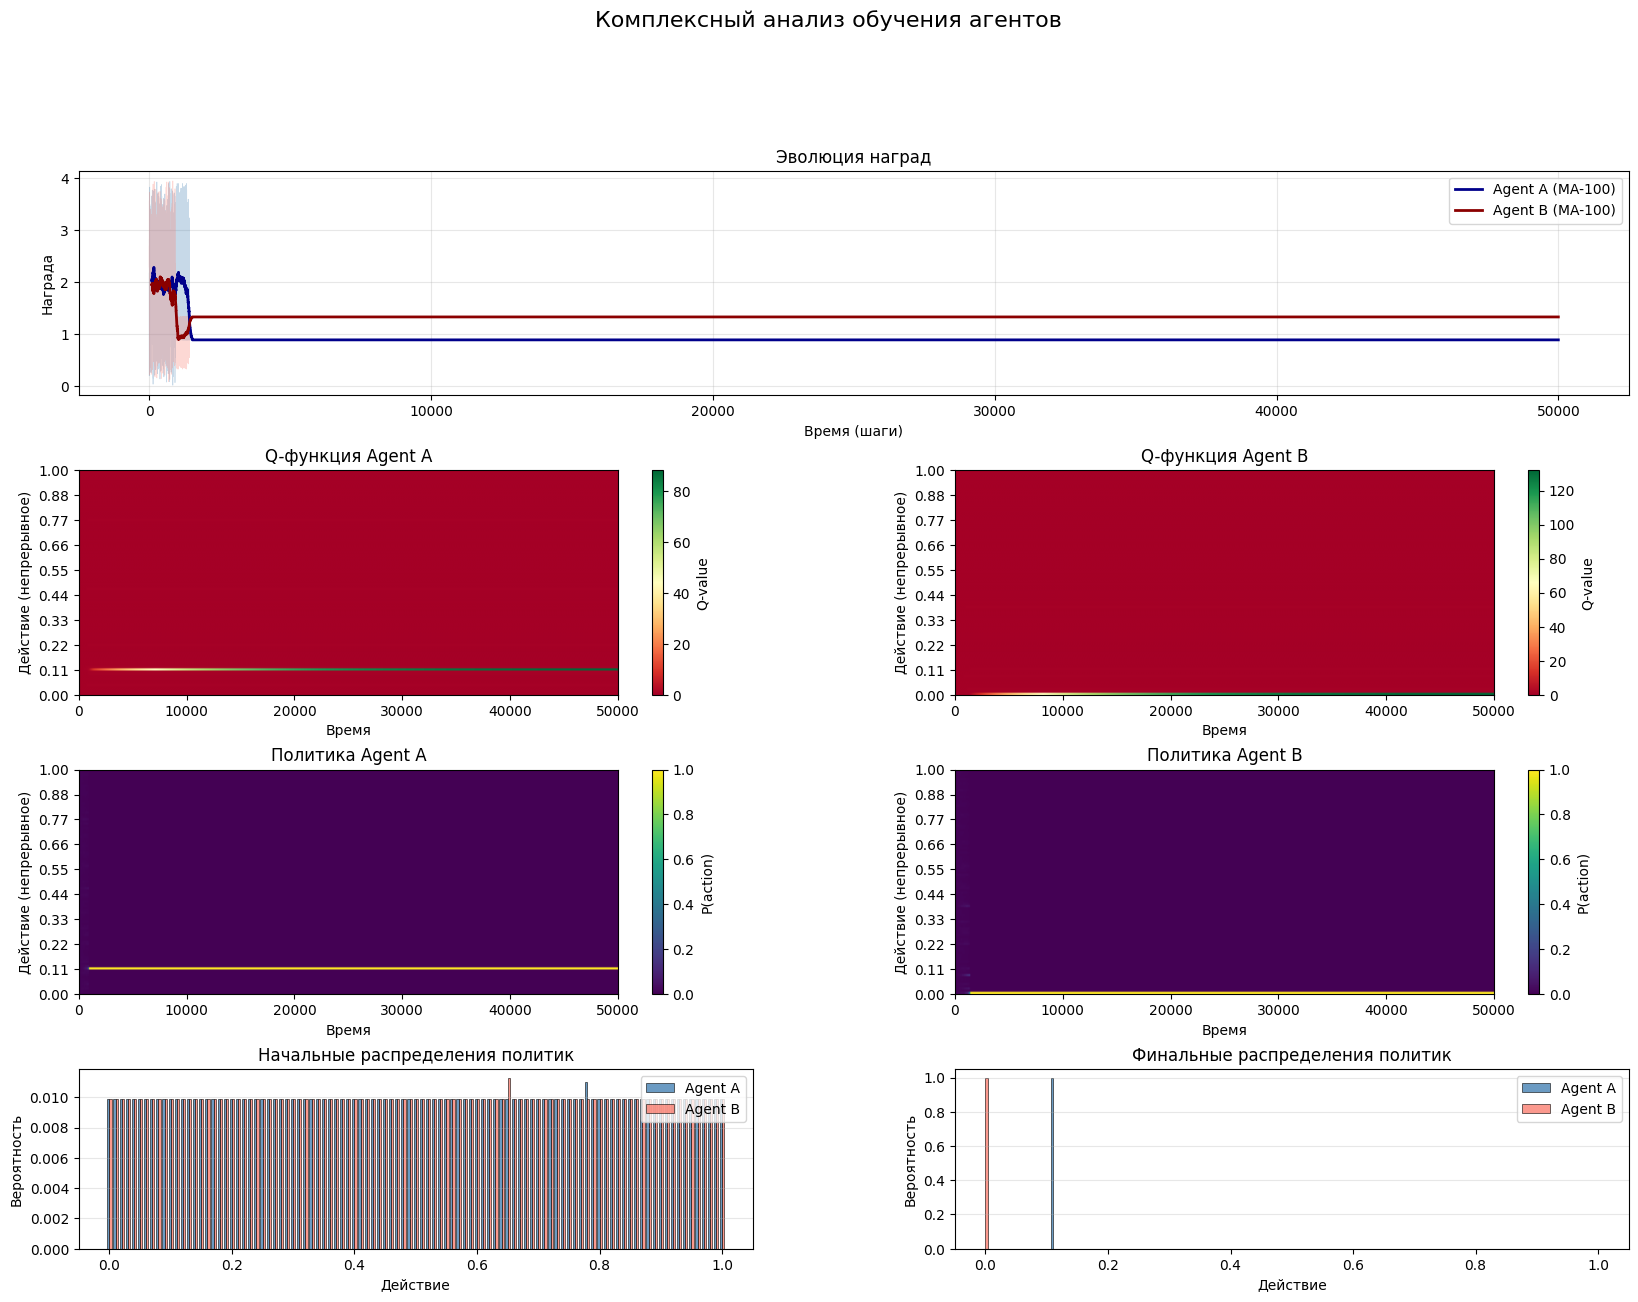

In [ ]:
# Создаём визуализации для сошедшихся экспериментов
from tqdm import tqdm as tqdm_bar

for i, exp in enumerate(tqdm_bar(converged_to_visualize, desc="Создание визуализаций")):
    beta = exp['beta']
    gamma = exp['gamma']
    
    # Формируем имя файла
    filename = f"beta{beta}_gamma{gamma}_converged.png"
    save_path = conv_dir / filename
    
    print(f"\n[{i+1}/{num_to_visualize}] β={beta}, γ={gamma}")
    print(f"  Действие A: {exp['conv_a']['argmax_value']:.3f} (p={exp['conv_a']['max_prob']:.3f})")
    print(f"  Действие B: {exp['conv_b']['argmax_value']:.3f} (p={exp['conv_b']['max_prob']:.3f})")
    
    # Запускаем полный эксперимент для получения всех данных
    data = run_full_experiment(
        beta=beta,
        gamma=gamma,
        params=params,
        n=n,
        steps=steps,
        alpha=alpha,
        init_mode=init_mode,
        seed=seed
    )
    
    # Создаём комплексную визуализацию
    plot_comprehensive_results(
        rewards_a=data['rewards_a'],
        rewards_b=data['rewards_b'],
        q_values_a=data['q_values_a'],
        q_values_b=data['q_values_b'],
        policies_a=data['policies_a'],
        policies_b=data['policies_b'],
        action_values=data['action_values'],
        window_size=100,
        save_path=str(save_path)
    )
    
    print(f"  ✅ Сохранено: {filename}")

print(f"\n✨ Готово! Создано {num_to_visualize} визуализаций в {conv_dir.absolute()}")


In [ ]:
# Создаём сводную таблицу сошедшихся экспериментов
print("\n" + "="*70)
print("📊 СВОДКА: СОШЕДШИЕСЯ ЭКСПЕРИМЕНТЫ")
print("="*70)

for i, exp in enumerate(converged_to_visualize):
    beta = exp['beta']
    gamma = exp['gamma']
    action_a = exp['conv_a']['argmax_value']
    action_b = exp['conv_b']['argmax_value']
    prob_a = exp['conv_a']['max_prob']
    prob_b = exp['conv_b']['max_prob']
    
    print(f"\n{i+1}. β={beta:>5.2f}, γ={gamma:>5.2f}")
    print(f"   Agent A: действие={action_a:.3f}, уверенность={prob_a:.3f}")
    print(f"   Agent B: действие={action_b:.3f}, уверенность={prob_b:.3f}")
    print(f"   Разность: |A-B|={abs(action_a - action_b):.3f}")
    print(f"   📁 Файл: beta{beta}_gamma{gamma}_converged.png")

print("\n" + "="*70)


📊 СВОДКА: СОШЕДШИЕСЯ ЭКСПЕРИМЕНТЫ

1. β= 0.90, γ= 0.30
   Agent A: действие=0.010, уверенность=0.016
   Agent B: действие=0.010, уверенность=0.017
   Разность: |A-B|=0.000
   📁 Файл: beta0.9_gamma0.3_converged.png

2. β= 0.90, γ= 0.70
   Agent A: действие=0.090, уверенность=0.021
   Agent B: действие=0.000, уверенность=0.021
   Разность: |A-B|=0.090
   📁 Файл: beta0.9_gamma0.7_converged.png

3. β= 2.00, γ= 0.90
   Agent A: действие=0.040, уверенность=1.000
   Agent B: действие=0.000, уверенность=0.208
   Разность: |A-B|=0.040
   📁 Файл: beta2.0_gamma0.9_converged.png

4. β= 2.00, γ= 0.95
   Agent A: действие=0.040, уверенность=1.000
   Agent B: действие=0.000, уверенность=1.000
   Разность: |A-B|=0.040
   📁 Файл: beta2.0_gamma0.95_converged.png

5. β= 2.00, γ= 0.99
   Agent A: действие=0.040, уверенность=1.000
   Agent B: действие=0.020, уверенность=1.000
   Разность: |A-B|=0.020
   📁 Файл: beta2.0_gamma0.99_converged.png

6. β= 5.00, γ= 0.70
   Agent A: действие=0.110, уверенность=1.